## paperfigs_rev01
Generate figures for paper (revision 01):


In [19]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from pathlib import Path
import pandas as pd

import sys
sys.path.insert(0, '/Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/src')
from utils import geosoft_cmap_k65
geosoft_cmap = geosoft_cmap_k65()


## Figure 1: ASM

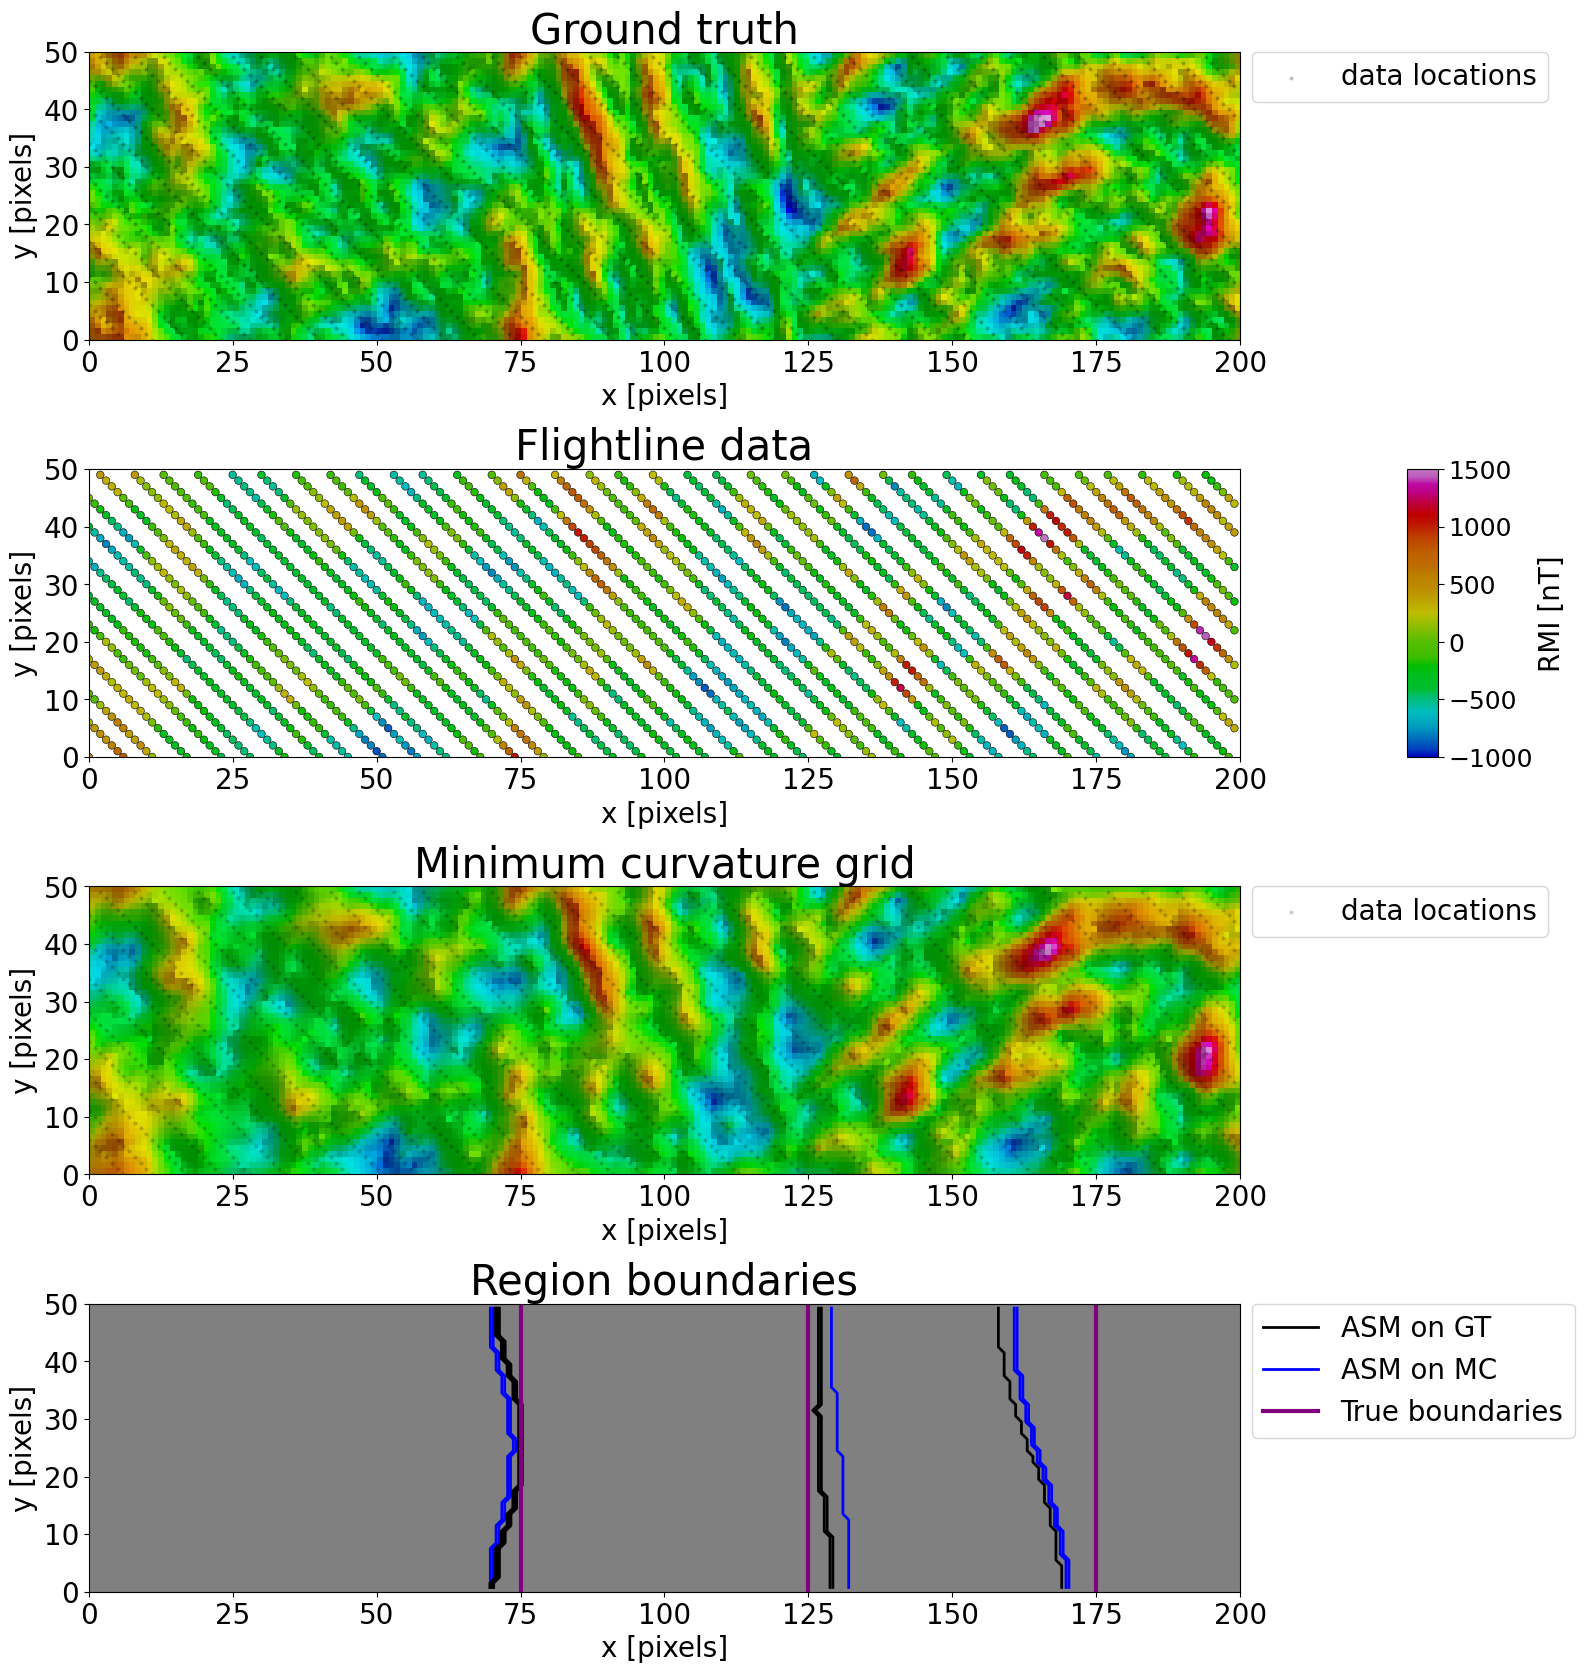

In [160]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LightSource
from matplotlib.cm import ScalarMappable
import matplotlib.gridspec as gridspec
import sys

sys.path.append('/Users/jrines/stanford_gp/research/mx/computers_geosciences/geosoft')
from geosoft_cmap_k65 import geosoft_cmap_k65

# --- load data ---
data_dir = "/Users/jrines/stanford_gp/research/mx/computers_geosciences/data"

# Ground truth (50 x 200 grid)
df_gt = pd.read_csv(f"{data_dir}/synthetic_magnetic_groundtruth.csv")
synthmag_gt = df_gt.values[:, 2].reshape(50, 200)

# Flightline observations
fl_xyv = np.loadtxt(f"{data_dir}/synthetic_flightlines.csv", delimiter=",", skiprows=1)

# Pre-computed intermediates (from demo_synthdata_asm.ipynb)
G = np.load(f"{data_dir}/grid_mc.npy")
segmentation_mc = np.load(f"{data_dir}/segmentation_mc.npy")
segmentation_gt = np.load(f"{data_dir}/segmentation_gt.npy")

# --- coloring ---
geosoft_cmap = geosoft_cmap_k65()
ls = LightSource(azdeg=120, altdeg=45)

vmin, vmax = -1000, 1500
norm = Normalize(vmin=vmin, vmax=vmax)

x, y, z = fl_xyv[:, 0], fl_xyv[:, 1], fl_xyv[:, 2]
xmin, xmax, ymin, ymax = 0, 200, 0, 50
extent = [xmin, xmax, ymin, ymax]

rgb_gt = ls.shade(synthmag_gt, cmap=geosoft_cmap, blend_mode='soft', vmin=vmin, vmax=vmax)
rgb_mc = ls.shade(G,           cmap=geosoft_cmap, blend_mode='soft', vmin=vmin, vmax=vmax)

# --- fonts ---
plt.rcParams.update({
    "axes.titlesize": 30, "axes.labelsize": 20,
    "xtick.labelsize": 20, "ytick.labelsize": 20, "legend.fontsize": 20,
})

# --- figure & GridSpec (4 rows) ---
fig = plt.figure(figsize=(22, 20))
gs = gridspec.GridSpec(
    4, 2, width_ratios=[60, 1], height_ratios=[1, 1, 1, 1],
    hspace=0.45, wspace=-0.2,
)

axs = [fig.add_subplot(gs[0, 0])]
axs += [fig.add_subplot(gs[i, 0], sharex=axs[0], sharey=axs[0]) for i in (1, 2)]
axb = fig.add_subplot(gs[3, 0], sharex=axs[0], sharey=axs[0])
cax = fig.add_subplot(gs[1, 1])

# (0) Ground truth
axs[0].imshow(rgb_gt, origin='lower', extent=extent, interpolation='nearest')
axs[0].scatter(x, y, c='k', s=8, alpha=0.25, linewidths=0, rasterized=True, label='data locations')
axs[0].set_title("Ground truth")
axs[0].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=True, borderaxespad=0.0)

# (1) Flightlines
axs[1].scatter(x, y, c=z, cmap=geosoft_cmap, norm=norm,
               s=30, edgecolors='k', linewidths=0.4, rasterized=True)
axs[1].set_title("Flightline data")

# (2) Minimum curvature grid
axs[2].imshow(rgb_mc, origin='lower', extent=extent, interpolation='nearest')
axs[2].scatter(x, y, c='k', s=8, alpha=0.2, linewidths=0, rasterized=True, label='data locations')
axs[2].set_title("Minimum curvature grid")
axs[2].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=True, borderaxespad=0.0)

# common formatting for top 3
for ax in axs:
    ax.set_xlim(0, 200); ax.set_ylim(0, 50)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel("x [pixels]"); ax.set_ylabel("y [pixels]")

# (3) Region boundaries
A, B = segmentation_mc, segmentation_gt
u = np.unique(np.concatenate([A.ravel(), B.ravel()]))
u.sort()
levels = (u[:-1] + u[1:]) / 2.0

ny, nx = A.shape
dx = (xmax - xmin) / nx
dy = (ymax - ymin) / ny
x_centers = xmin + dx * (0.5 + np.arange(nx))
y_centers = ymin + dy * (0.5 + np.arange(ny))
XX, YY = np.meshgrid(x_centers, y_centers)

axb.imshow(np.ones_like(A), origin='lower', extent=extent, cmap="gray", vmin=0, vmax=2)
axb.contour(XX, YY, A, levels=levels, colors="blue",  linewidths=2.0, linestyles="solid")
axb.contour(XX, YY, B, levels=levels, colors="black", linewidths=2.0, linestyles="solid")

for tx in [75, 125, 175]:
    axb.axvline(x=tx, color="purple", linestyle="solid", linewidth=3)

mc_proxy   = plt.Line2D([0], [0], color="blue",   linewidth=2.0, linestyle="solid")
gt_proxy   = plt.Line2D([0], [0], color="black",  linewidth=2.0, linestyle="solid")
true_proxy = plt.Line2D([0], [0], color="purple", linewidth=3.0, linestyle="solid")
axb.legend([gt_proxy, mc_proxy, true_proxy],
           ["ASM on GT", "ASM on MC", "True boundaries"],
           loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=True, borderaxespad=0.0)

axb.set_title("Region boundaries")
axb.set_xlim(0, 200); axb.set_ylim(0, 50)
axb.set_aspect("equal", adjustable="box")
axb.set_xlabel("x [pixels]"); axb.set_ylabel("y [pixels]")

# shared colorbar
mappable = ScalarMappable(norm=norm, cmap=geosoft_cmap)
mappable.set_array([])
cbar = fig.colorbar(mappable, cax=cax)
cbar.set_label("RMI [nT]", fontsize=20)
cbar.ax.tick_params(labelsize=18, length=4)

# save fig
fig.savefig("/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/figures/fig01_asm.png",
            bbox_inches='tight', dpi=300)

plt.show()


## Figure 2: trend and residuals

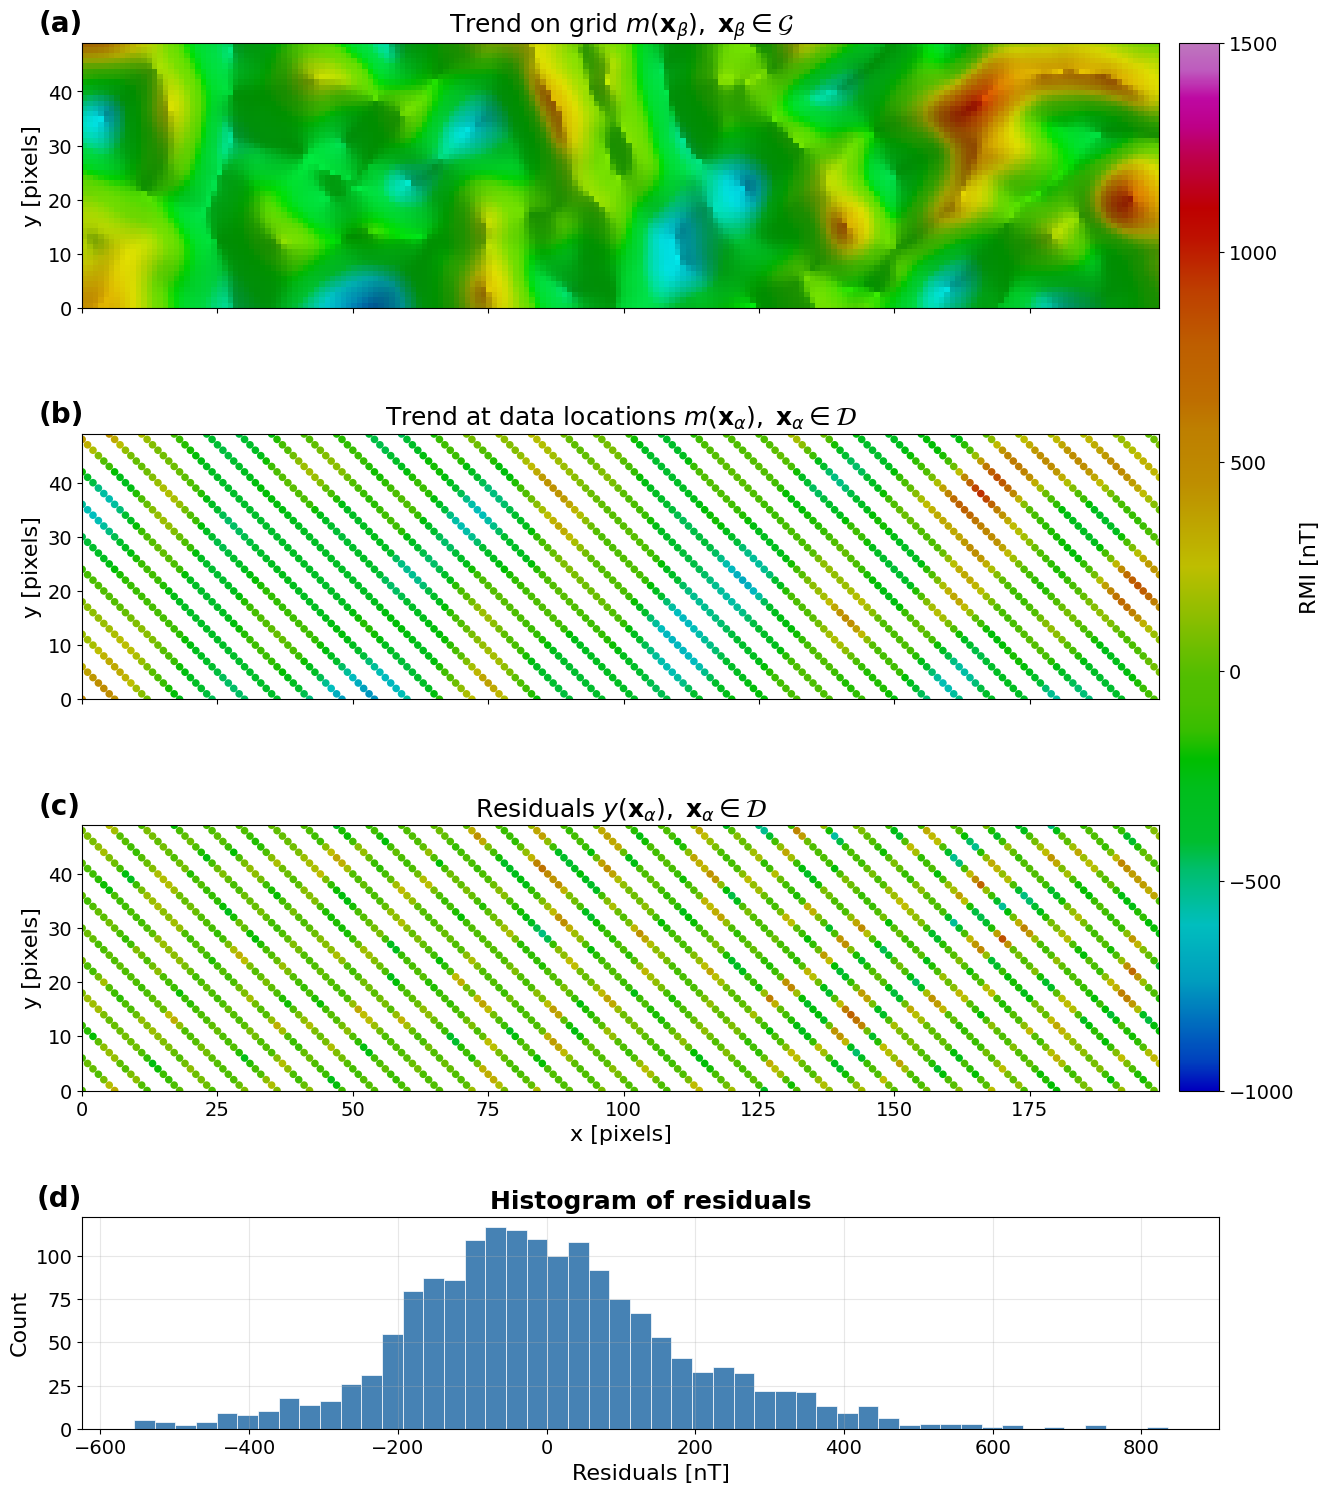

In [282]:
## FIGURE 2: Trend decomposition — trend grid, trend at data, residuals ##
## ==================================================================== ##

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize, LightSource
from matplotlib.cm import ScalarMappable
from pathlib import Path
import sys

sys.path.insert(0, '/Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/src')
from utils import geosoft_cmap_k65

geosoft_cmap = geosoft_cmap_k65()
ls = LightSource(azdeg=120, altdeg=45)

# --- Load config + data CSV ---
cfg_dir = Path('/Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/configs')

with open(cfg_dir / f'config_sph_iso_subregions_{linespacing}.json') as f:
    config = json.load(f)

df_all = pd.read_csv(cfg_dir / config['data_file'])
rows, cols = tuple(config['grid_shape'])  # (50, 200)

# --- Reconstruct trend grid ---
sim_mask = df_all['cluster'] >= 0
trend_grid = np.full(rows * cols, np.nan)
trend_grid[sim_mask.values] = df_all.loc[sim_mask, 'trend'].values
trend_grid = trend_grid.reshape(rows, cols)

# --- Observation points ---
obs = df_all[df_all['set'] == 1].copy()
obs_x, obs_y = obs['x'].values, obs['y'].values
obs_trend = obs['trend'].values
obs_residual = obs['residual'].values

# --- Color scaling ---
vmin, vmax = -1000, 1500
norm = Normalize(vmin=vmin, vmax=vmax)
extent = [0, cols - 1, 0, rows - 1]

# --- Hillshade ---
rgb_trend = ls.shade(np.nan_to_num(trend_grid, nan=0), cmap=geosoft_cmap,
                     blend_mode='soft', vmin=vmin, vmax=vmax)

# --- Fonts ---
plt.rcParams.update({
    "axes.titlesize": 18, "axes.labelsize": 16,
    "xtick.labelsize": 14, "ytick.labelsize": 14,
})

# --- Figure layout ---
fig = plt.figure(figsize=(20, 18))
gs = gridspec.GridSpec(
    4, 2,
    width_ratios=[60, 1],
    height_ratios=[1, 1, 1, 0.8],
    hspace=0.5,
    wspace=0.05,
)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[1, 0], sharex=ax_a, sharey=ax_a)
ax_c = fig.add_subplot(gs[2, 0], sharex=ax_a, sharey=ax_a)
ax_d = fig.add_subplot(gs[3, 0])
cax  = fig.add_subplot(gs[:3, 1])

# (a) Trend on grid — hillshaded raster
ax_a.imshow(rgb_trend, origin='lower', extent=extent, interpolation='nearest')
ax_a.set_title(r'Trend on grid $m(\mathbf{x}_\beta),\; \mathbf{x}_\beta \in \mathcal{G}$')
ax_a.set_ylabel('y [pixels]')
ax_a.set_xlim(0, cols - 1)
ax_a.set_ylim(0, rows - 1)
ax_a.set_aspect('equal', adjustable='box')
ax_a.text(-0.04, 1.02, '(a)', transform=ax_a.transAxes,
          fontsize=20, fontweight='bold', va='bottom')
plt.setp(ax_a.get_xticklabels(), visible=False)

# (b) Trend at data locations — scatter
ax_b.scatter(obs_x, obs_y, c=obs_trend, cmap=geosoft_cmap, norm=norm,
             s=30, linewidths=0, rasterized=True)
ax_b.set_title(r'Trend at data locations $m(\mathbf{x}_\alpha),\; \mathbf{x}_\alpha \in \mathcal{D}$')
ax_b.set_ylabel('y [pixels]')
ax_b.set_aspect('equal', adjustable='box')
ax_b.text(-0.04, 1.02, '(b)', transform=ax_b.transAxes,
          fontsize=20, fontweight='bold', va='bottom')
plt.setp(ax_b.get_xticklabels(), visible=False)

# (c) Residuals at data locations — scatter
ax_c.scatter(obs_x, obs_y, c=obs_residual, cmap=geosoft_cmap, norm=norm,
             s=30, linewidths=0, rasterized=True)
ax_c.set_title(r'Residuals $y(\mathbf{x}_\alpha),\; \mathbf{x}_\alpha \in \mathcal{D}$')
ax_c.set_xlabel('x [pixels]')
ax_c.set_ylabel('y [pixels]')
ax_c.set_aspect('equal', adjustable='box')
ax_c.text(-0.04, 1.02, '(c)', transform=ax_c.transAxes,
          fontsize=20, fontweight='bold', va='bottom')

# Shared colorbar for (a)-(c)
mappable = ScalarMappable(norm=norm, cmap=geosoft_cmap)
mappable.set_array([])
cbar = fig.colorbar(mappable, cax=cax)
cbar.set_label('RMI [nT]', fontsize=16)
cbar.ax.tick_params(labelsize=14)

# (d) Histogram of residuals
ax_d.hist(obs_residual, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
ax_d.set_xlabel('Residuals [nT]', fontsize=16)
ax_d.set_ylabel('Count', fontsize=16)
ax_d.set_title('Histogram of residuals', fontsize=18, fontweight='bold')
ax_d.tick_params(labelsize=14)
ax_d.grid(True, alpha=0.3)
ax_d.text(-0.04, 1.02, '(d)', transform=ax_d.transAxes,
          fontsize=20, fontweight='bold', va='bottom')

# Align histogram and colorbar with the map panels
fig.canvas.draw()
pos_a = ax_a.get_position()
pos_c = ax_c.get_position()
pos_d = ax_d.get_position()

cax.set_position([pos_c.x1 + 0.01, pos_c.y0, 0.02, pos_a.y1 - pos_c.y0])
cbar_right = pos_c.x1 + 0.03
ax_d.set_position([pos_c.x0, pos_d.y0, cbar_right - pos_c.x0, pos_d.height])

# save fig
fig.savefig("/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/figures/fig02_trend.png",
            bbox_inches='tight', dpi=300)

plt.show()


## Figure 3: data points and cluster variograms synthetic

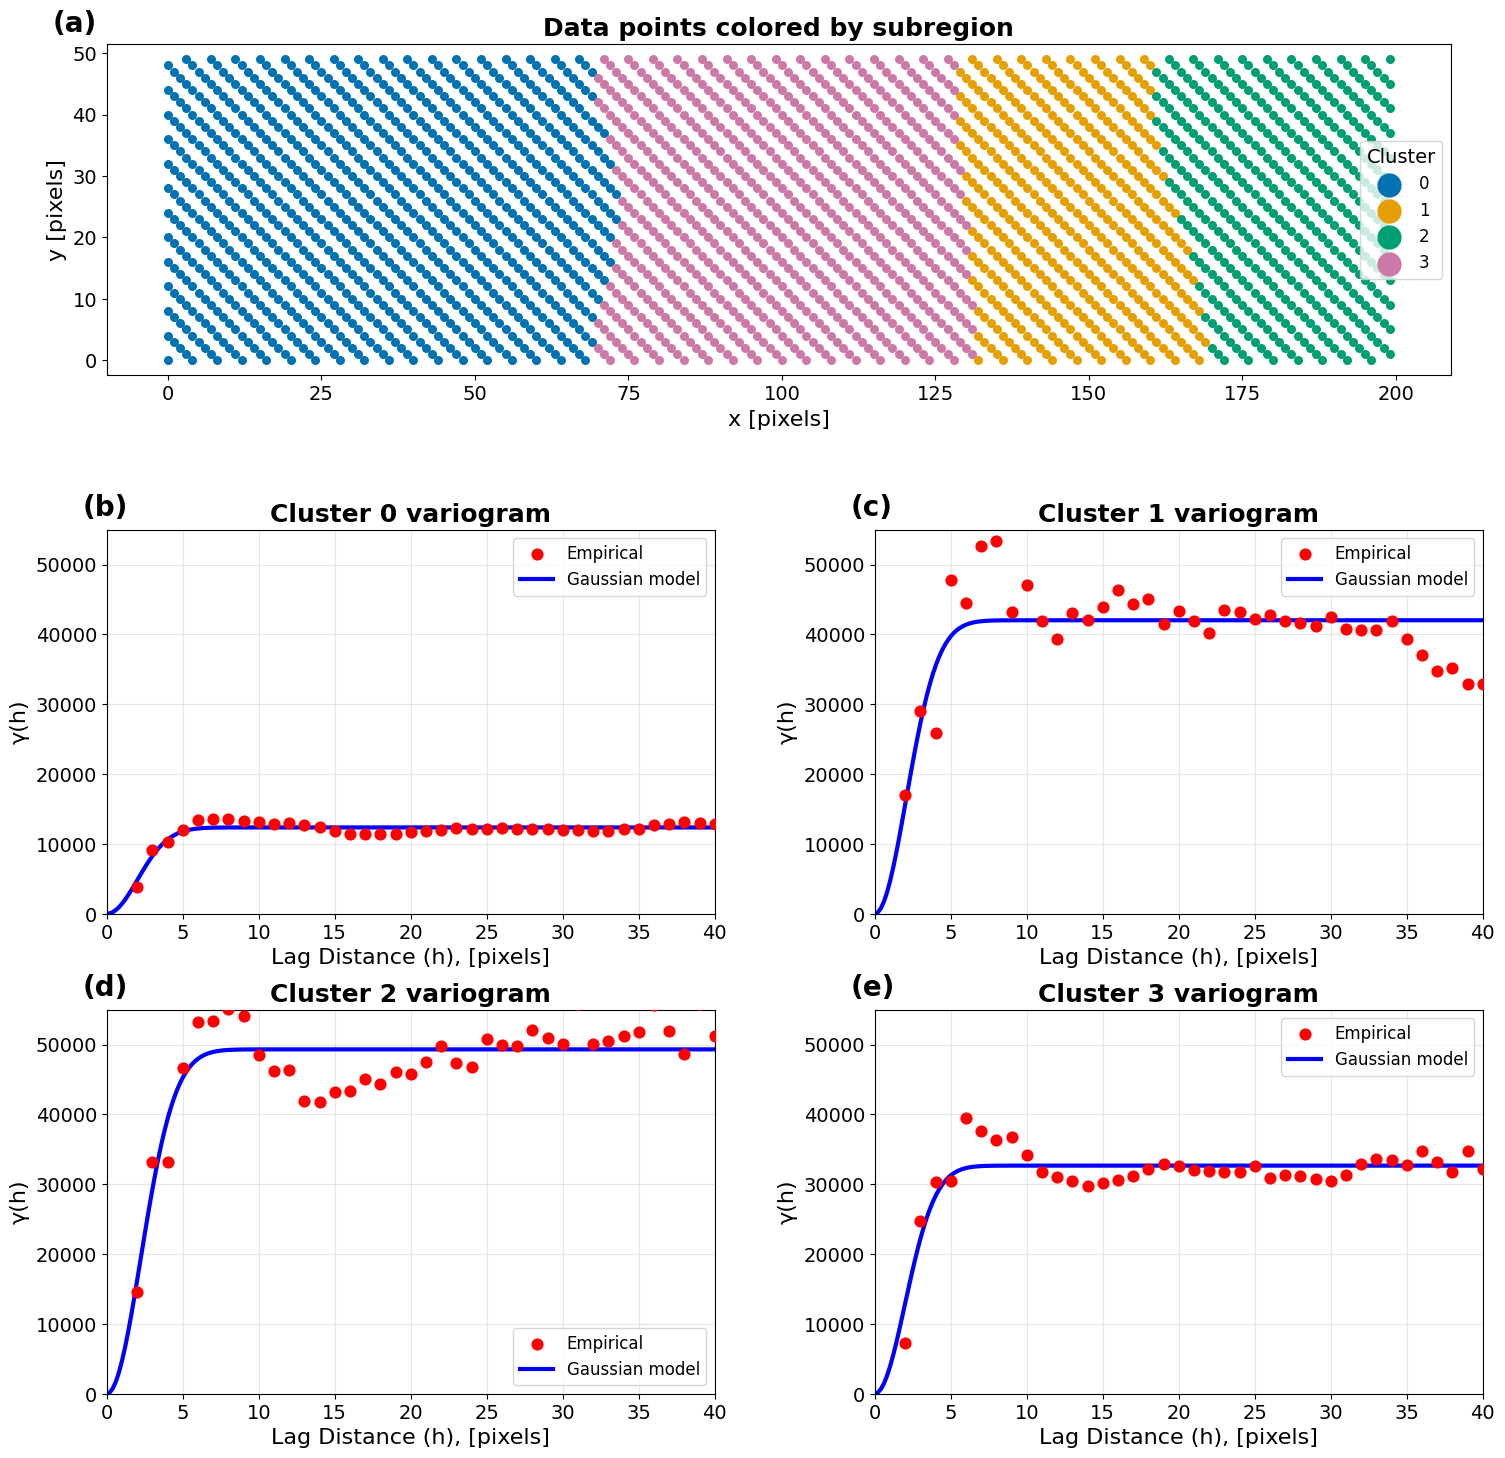


Fitted Gaussian variogram parameters:
Cluster    Range        Sill         Nugget      
----------------------------------------------
0          5.71         12357.8      0.0000      
1          5.86         42033.6      0.0000      
2          6.33         49322.4      0.0000      
3          5.63         32670.6      0.0000      


In [283]:
## FIGURE: Data points + cluster variograms (Gaussian) ##
## =================================================== ##

import sys
sys.path.insert(0, '/Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/src')
from variograms import cluster_variogram
import json

# --- Load flight line data ---
fl_path = '/Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/demos/data/fl_xyvc_dense.csv'
df_fl = pd.read_csv(fl_path)
df_fl.columns = ['x', 'y', 'value', 'cluster']
df_fl['cluster'] = df_fl['cluster'].astype(int)

# --- Load config data (for trend / residuals) ---
cfg_data = pd.read_csv('/Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/configs/config_iso_subregions_dense_data.csv')
obs = cfg_data[cfg_data['set'] == 1].copy()
df_fl = df_fl.merge(obs[['x', 'y', 'residual']], on=['x', 'y'], how='left')

# --- Variogram parameters ---
maxlag = 40
n_lags = 40
model = 'gaussian'
n_clusters = df_fl['cluster'].nunique()

variograms = []
for i in range(n_clusters):
    V = cluster_variogram(df_fl, 'residual', i, maxlag, n_lags, model)
    variograms.append(V)

# --- Colorblind-safe palette (Wong 2011) ---
cluster_colors = {
    0: '#0072B2',  # blue
    1: '#E69F00',  # orange
    2: '#009E73',  # green
    3: '#CC79A7',  # pink
}

# --- Build figure ---
fig = plt.figure(figsize=(16, 16))

# (a) Data points colored by subregion
ax_a = fig.add_axes([0.08, 0.64, 0.84, 0.28])
for ci in range(n_clusters):
    mask = df_fl['cluster'] == ci
    ax_a.scatter(df_fl.loc[mask, 'x'], df_fl.loc[mask, 'y'],
                 c=cluster_colors[ci], s=30, label=f'{ci}', rasterized=True)
ax_a.set_xlabel('x [pixels]', fontsize=16)
ax_a.set_ylabel('y [pixels]', fontsize=16)
ax_a.set_title('Data points colored by subregion', fontsize=18, fontweight='bold')
ax_a.set_aspect('equal')
ax_a.legend(title='Cluster', markerscale=3, fontsize=12, title_fontsize=14)
ax_a.tick_params(labelsize=14)
ax_a.text(-0.04, 1.02, '(a)', transform=ax_a.transAxes, fontsize=20, fontweight='bold', va='bottom')

# (b-e) Cluster variograms
panel_labels = ['(b)', '(c)', '(d)', '(e)']
positions = [
    [0.08, 0.34, 0.38, 0.24],
    [0.56, 0.34, 0.38, 0.24],
    [0.08, 0.04, 0.38, 0.24],
    [0.56, 0.04, 0.38, 0.24],
]

for i, V in enumerate(variograms):
    ax = fig.add_axes(positions[i])

    # Empirical variogram points
    ax.scatter(V.bins, V.experimental, c='red', s=60, zorder=3, label='Empirical')

    # Fitted model curve
    h = np.linspace(0, V.bins[-1], 200)
    gamma_model = V.transform(h)
    ax.plot(h, gamma_model, color='blue', linewidth=3, label='Gaussian model')

    r, s, n = V.parameters
    ax.set_xlabel('Lag Distance (h), [pixels]', fontsize=16)
    ax.set_ylabel('γ(h)', fontsize=16)
    ax.set_title(f'Cluster {i} variogram', fontsize=18, fontweight='bold')
    ax.set_xlim(0, maxlag)
    ax.set_ylim(0, 55000)
    ax.legend(fontsize=12)
    ax.tick_params(labelsize=14)
    ax.grid(True, alpha=0.3)
    ax.text(-0.04, 1.02, panel_labels[i], transform=ax.transAxes,
            fontsize=20, fontweight='bold', va='bottom')

# save fig
fig.savefig("/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/figures/fig03_clusters.png",
            bbox_inches='tight', dpi=300)

plt.show()

# Print fitted parameters
print("\nFitted Gaussian variogram parameters:")
print(f"{'Cluster':<10} {'Range':<12} {'Sill':<12} {'Nugget':<12}")
print("-" * 46)
for i, V in enumerate(variograms):
    r, s, n = V.parameters
    print(f"{i:<10} {r:<12.2f} {s:<12.1f} {n:<12.4f}")


## Figure 4: mgsim iterations

In [291]:
## --- Run MGSIM loop, capturing intermediates ---
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path

sys.path.insert(0, '/Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/src')
import gstatsim as gs
from sampling import subsample_dataframe
from utils import geosoft_cmap_k65

geosoft_cmap = geosoft_cmap_k65()

# --- Load config ---
cfg_dir = Path('/Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/configs')
with open(cfg_dir / 'config_sph_iso_subregions_dense.json') as f:
    config = json.load(f)

df_xyvtcs = pd.read_csv(cfg_dir / config['data_file'])
df_gamma = pd.DataFrame({'Variogram': config['variograms_list']})
mg_resols = config['mg_resols']
grid_shape = tuple(config['grid_shape'])  # (50, 200)
rows, cols = grid_shape
kw = config['mgsim_kwargs']
xx, yy, zz, kk = kw['xx'], kw['yy'], kw['zz'], kw['kk']
num_points, radius = kw['num_points'], kw['radius']

# --- Run MGSIM loop, capturing intermediates ---
np.random.seed(42)

df_all = df_xyvtcs.copy()
sim_mask = df_all[kk] >= 0
df = df_all.loc[sim_mask].copy()
pred_xy_grid = df[['x', 'y']].values
df['residual'] = df['value'] - df['trend']
df['newtrend'] = df['trend'].copy()

snapshots = []

for i, mg_resol in enumerate(mg_resols):
    print(f"Iteration {i+1}/{len(mg_resols)}: resolution={mg_resol}")

    df_obspts = df[df['set'] == 1].copy()
    if i < len(mg_resols) - 1:
        df_mgsmpl = subsample_dataframe(df_obspts, column_for_sampling='residual', spacing=mg_resol)
    else:
        df_mgsmpl = df_obspts.copy()

    mgsgs = gs.Interpolation.cluster_sgs(
        pred_xy_grid, df_mgsmpl, xx, yy, zz, kk, num_points, df_gamma, radius
    )

    df['newtrend'] = df['newtrend'] + mgsgs
    df['residual'] = df['value'] - df['newtrend']

    # # Update subsampled points with post-SGS residuals
    # df_mgsmpl['residual'] = df.loc[df_mgsmpl.index, 'residual'].values

    # Capture snapshot
    newtrend_grid = np.full(rows * cols, np.nan)
    newtrend_grid[sim_mask.values] = df['newtrend'].values
    newtrend_grid = newtrend_grid.reshape(rows, cols)

    snapshots.append({
        'iter': i + 1,
        'mg_resol': mg_resol,
        'df_mgsmpl': df_mgsmpl.copy(),
        'obs_residuals': df.loc[df['set'] == 1, 'residual'].values.copy(),
        'newtrend_grid': newtrend_grid,
        'n_subsampled': len(df_mgsmpl),
    })

print(f"\nDone! Captured {len(snapshots)} snapshots.")

Iteration 1/8: resolution=20


100%|██████████| 10000/10000 [00:30<00:00, 327.86it/s]


Iteration 2/8: resolution=15


100%|██████████| 10000/10000 [00:30<00:00, 322.99it/s]


Iteration 3/8: resolution=10


...

Iteration 7/8: resolution=2


100%|██████████| 10000/10000 [00:23<00:00, 420.49it/s]


Iteration 8/8: resolution=1


100%|██████████| 10000/10000 [00:23<00:00, 425.62it/s]


Done! Captured 8 snapshots.


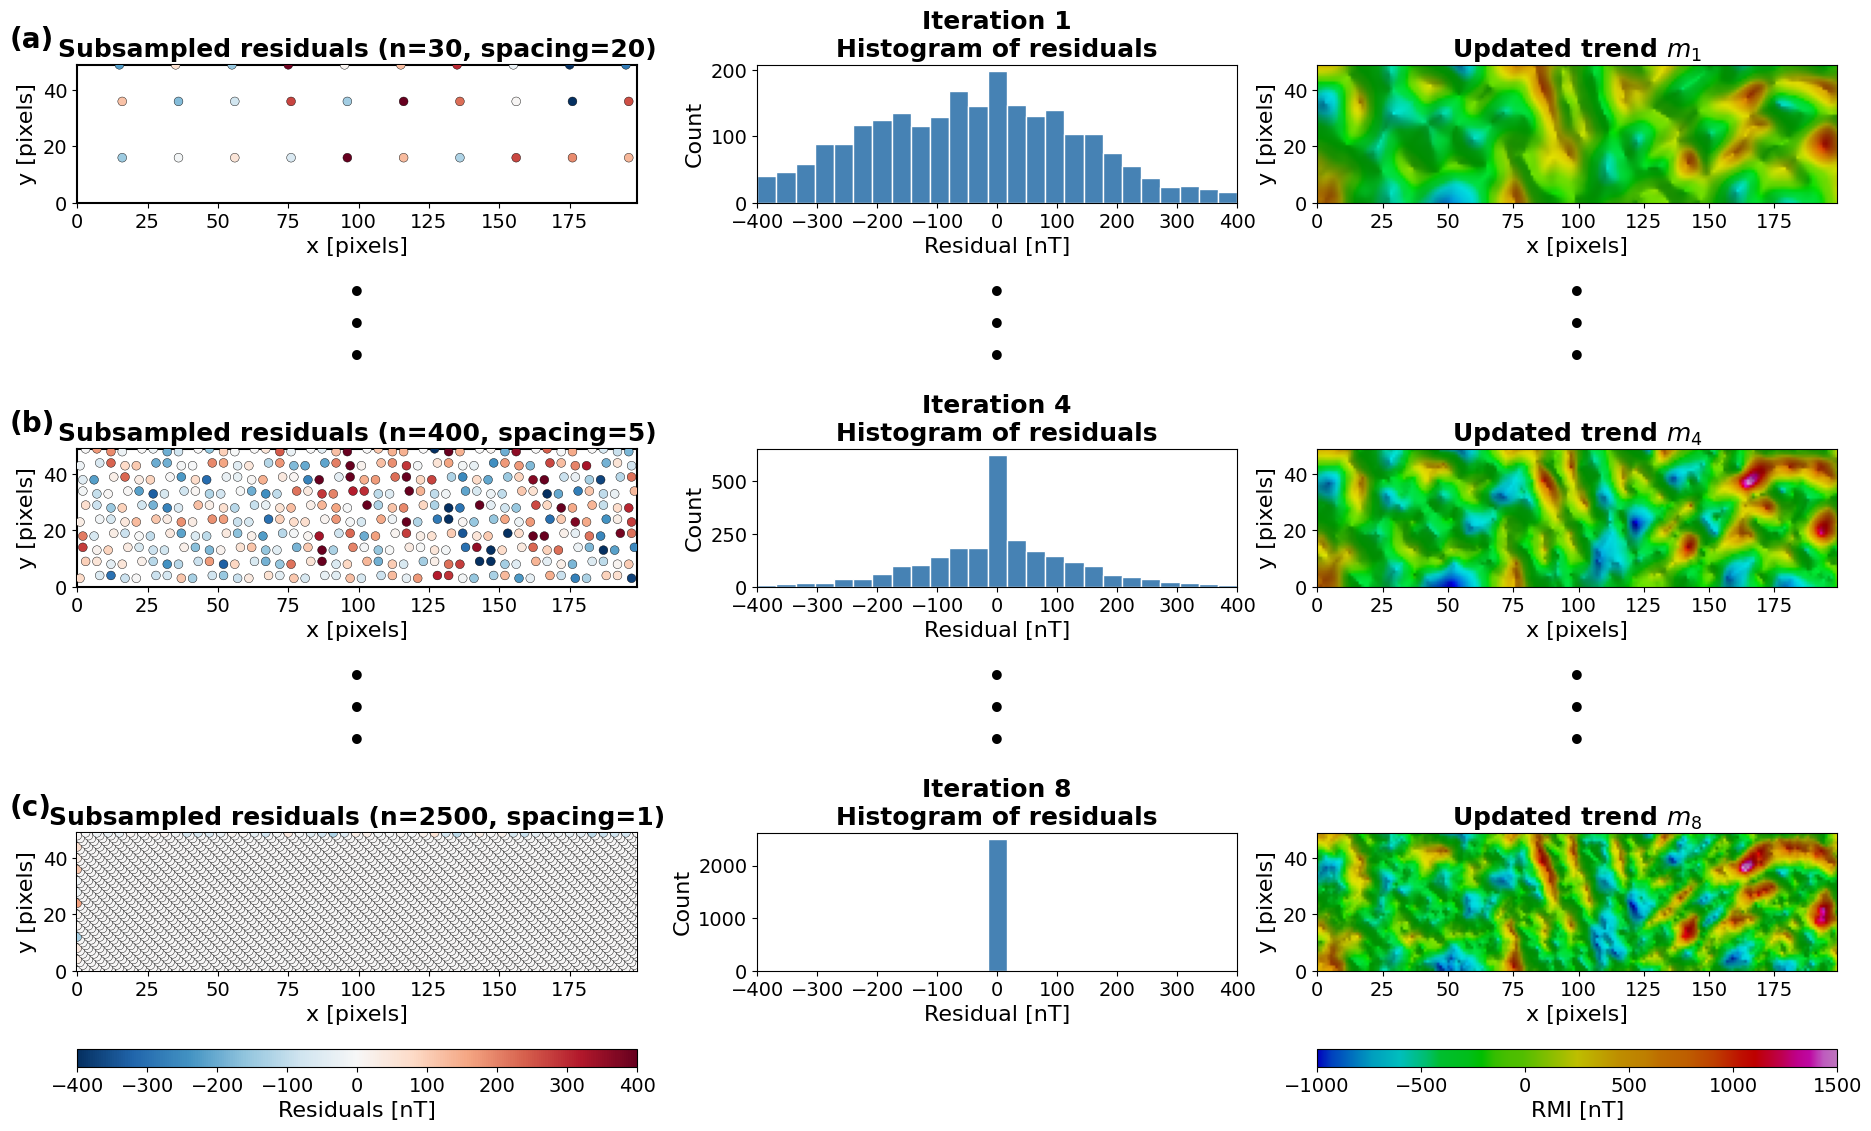

In [296]:
## FIGURE: MGSIM Iteration Visualization (inline, single realization) ##
## =================================================================== ##

from matplotlib.colors import TwoSlopeNorm, LightSource, Normalize
from matplotlib.cm import ScalarMappable

# --- Plot iterations 1, 4, and last ---
show_iters = [0, 3, len(snapshots) - 1]
panel_labels = ['(a)', '(b)', '(c)']

extent = [0, cols - 1, 0, rows - 1]
vmin, vmax = -1000, 1500
ls = LightSource(azdeg=315, altdeg=45)

fig_w, fig_h = 20, 12
fig = plt.figure(figsize=(fig_w, fig_h))

data_aspect = (rows - 1) / (cols - 1)
pw_map = 0.28
ph = pw_map * data_aspect * (fig_w / fig_h)

col_xs = [0.06, 0.40, 0.68]
col_w = [pw_map, 0.24, 0.26]
row_ys = [0.76, 0.44, 0.12]

res_norm = TwoSlopeNorm(vmin=-400, vcenter=0, vmax=400)
res_cmap = plt.cm.RdBu_r

for ri, (si, plabel) in enumerate(zip(show_iters, panel_labels)):
    snap = snapshots[si]
    y0 = row_ys[ri]

    # --- Left: Subsampled points colored by residual ---
    ax_pts = fig.add_axes([col_xs[0], y0, col_w[0], ph])
    sc = ax_pts.scatter(snap['df_mgsmpl']['x'], snap['df_mgsmpl']['y'],
                        c=snap['df_mgsmpl']['residual'],
                        cmap=res_cmap, norm=res_norm,
                        s=40, zorder=3, edgecolors='k', linewidths=0.3)
    ax_pts.set_xlim(extent[0], extent[1])
    ax_pts.set_ylim(extent[2], extent[3])
    ax_pts.set_aspect('auto')
    for spine in ax_pts.spines.values():
        spine.set_linewidth(1.5)

    ax_pts.set_xlabel('x [pixels]', fontsize=16)
    ax_pts.set_ylabel('y [pixels]', fontsize=16)
    ax_pts.set_title(
        f'Subsampled residuals '
        f'(n={snap["n_subsampled"]}, spacing={snap["mg_resol"]})',
        fontsize=18, fontweight='bold'
    )
    ax_pts.tick_params(labelsize=14)
    ax_pts.text(-0.12, 1.08, plabel, transform=ax_pts.transAxes,
                fontsize=20, fontweight='bold', va='bottom')

    # --- Middle: Histogram of observation residuals ---
    ax_hist = fig.add_axes([col_xs[1], y0, col_w[1], ph])
    ax_hist.hist(snap['obs_residuals'], bins=25, range=(-400, 400),
                 color='steelblue', edgecolor='white')
    ax_hist.set_xlabel('Residual [nT]', fontsize=16)
    ax_hist.set_ylabel('Count', fontsize=16)
    ax_hist.set_title(f'Iteration {snap["iter"]}\nHistogram of residuals',
                      fontsize=18, fontweight='bold')
    ax_hist.set_xlim(-400, 400)
    ax_hist.tick_params(labelsize=14)

    # --- Right: Updated trend map (hillshaded) ---
    ax_map = fig.add_axes([col_xs[2], y0, col_w[2], ph])
    rgb = ls.shade(snap['newtrend_grid'], cmap=geosoft_cmap,
                   blend_mode='soft', vmin=vmin, vmax=vmax)
    ax_map.imshow(rgb, origin='lower', extent=extent, aspect='auto')
    ax_map.set_xlabel('x [pixels]', fontsize=16)
    ax_map.set_ylabel('y [pixels]', fontsize=16)
    ax_map.set_title(f'Updated trend $m_{snap["iter"]}$',
                     fontsize=18, fontweight='bold')
    ax_map.tick_params(labelsize=14)

# Residual colorbar below left column
res_mappable = ScalarMappable(norm=res_norm, cmap=res_cmap)
res_mappable.set_array([])
rcbar_ax = fig.add_axes([col_xs[0], 0.04, col_w[0], 0.015])
rcb = fig.colorbar(res_mappable, cax=rcbar_ax, orientation='horizontal')
rcb.set_label('Residuals [nT]', fontsize=16)
rcb.ax.tick_params(labelsize=14)

# Value colorbar below right column
val_mappable = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=geosoft_cmap)
val_mappable.set_array([])
vcbar_ax = fig.add_axes([col_xs[2], 0.04, col_w[2], 0.015])
vcb = fig.colorbar(val_mappable, cax=vcbar_ax, orientation='horizontal')
vcb.set_label('RMI [nT]', fontsize=16)
vcb.ax.tick_params(labelsize=14)

# Ellipsis in each column between rows
col_centers = [col_xs[i] + col_w[i] / 2 for i in range(3)]
for ry_top, ry_bot in [(row_ys[0], row_ys[1]), (row_ys[1], row_ys[2])]:
    dot_y = (ry_top + ry_bot + ph) / 2
    for cx in col_centers:
        fig.text(cx, dot_y, '\u2022\n\u2022\n\u2022', ha='center', va='center',
                 fontsize=20, fontweight='bold')

# save fig
fig.savefig("/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/figures/fig04_mgiters.png",
            bbox_inches='tight', dpi=300)

plt.show()


## LOAD RESULTS FROM SYNTHETIC SIMULATIONS

In [297]:
## LOAD SYNTHETIC ENSEMBLE RESULTS ##
## ================================ ##

from pathlib import Path
import xarray as xr

# ---- SELECT HERE ----
variogram_type = 'gaussian'   # 'spherical' or 'gaussian'
linespacing    = 'medium'      # 'dense', 'medium', or 'sparse'
# ---------------------

vgram_dir = {'spherical': 'sph_vgram', 'gaussian': 'gauss_vgram'}[variogram_type]
base = Path('/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/sherlock') / vgram_dir

print(f"Variogram: {variogram_type}  |  Linespacing: {linespacing}")
print(f"Loading from: {base}")

# SGSIM (standard single-pass)
sgsim_files = sorted((base / 'standard_geostats' / linespacing).glob('sgsim_realizations_*.nc'))
ds_sgsim = xr.open_mfdataset(sgsim_files, combine='nested', concat_dim='realization').sortby('realization')

# MGSIM (multigrid, subregion variograms)
mgsim_files = sorted((base / f'iso_subregions_{linespacing}').glob('realizations_*.nc'))
ds_mgsim = xr.open_mfdataset(mgsim_files, combine='nested', concat_dim='realization').sortby('realization')

# Kriging
ds_krig = xr.open_dataset(base / 'standard_geostats' / linespacing / 'kriging_result.nc')

# Precompute statistics
sgsim_mean = ds_sgsim['simulated'].mean(dim='realization').values
mgsim_mean = ds_mgsim['simulated'].mean(dim='realization').values
mgsim_var  = ds_mgsim['simulated'].var(dim='realization').values
krig_pred  = ds_krig['kriging_pred'].values

print(f"SGSIM: {ds_sgsim.sizes['realization']} realizations")
print(f"MGSIM: {ds_mgsim.sizes['realization']} realizations")

Variogram: gaussian  |  Linespacing: medium
Loading from: /Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/sherlock/gauss_vgram
SGSIM: 1000 realizations
MGSIM: 1000 realizations


## Figure 5: Synthetic results comparison

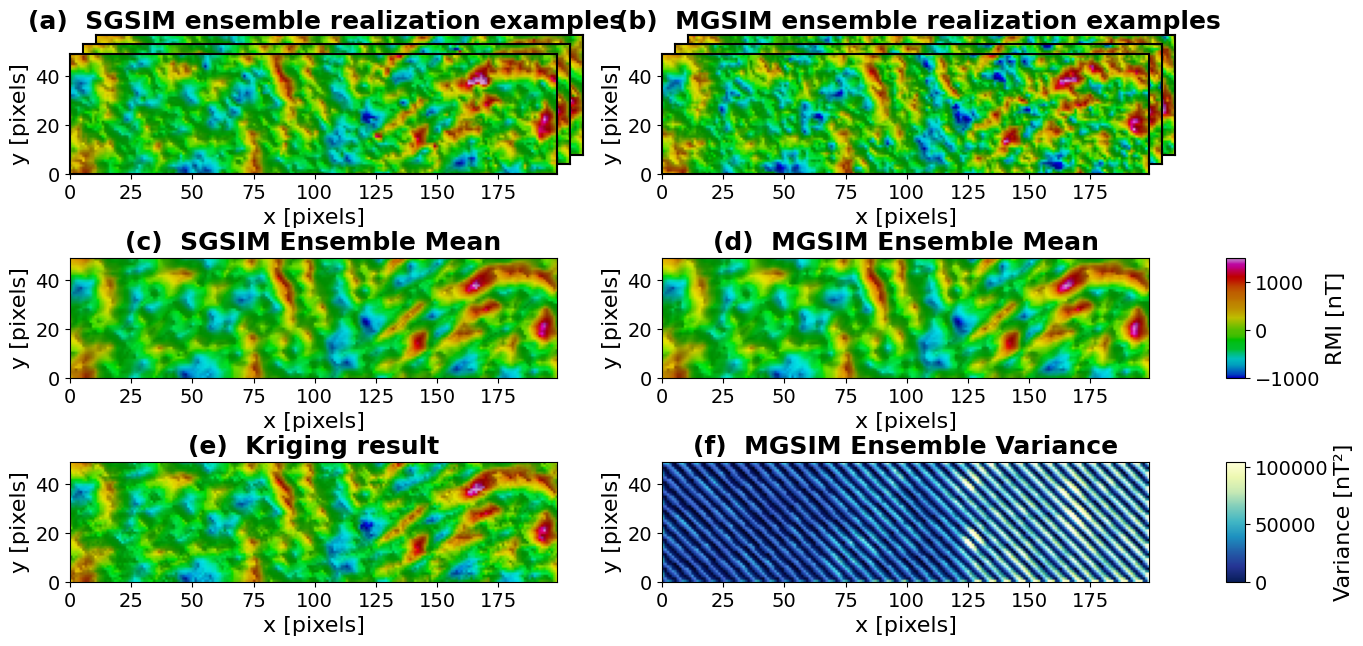

In [298]:
## FIGURE 5: SGSIM vs MGSIM comparison (6-panel, hillshade) ##
## ========================================================= ##

from matplotlib.colors import Normalize, LightSource
from matplotlib.cm import ScalarMappable

ls = LightSource(azdeg=315, altdeg=45)
vmin, vmax = -1000, 1500

extent = [float(ds_mgsim.x.min()), float(ds_mgsim.x.max()),
          float(ds_mgsim.y.min()), float(ds_mgsim.y.max())]

def shade(mat, cmap, vmin, vmax):
    return ls.shade(mat, cmap=cmap, blend_mode='soft', vmin=vmin, vmax=vmax)

def draw_stacked(fig, rect, ds, real_indices, cmap, vmin, vmax, label):
    n = len(real_indices)
    dx, dy = 0.008, 0.008

    for i, ridx in enumerate(real_indices):
        mat = ds['simulated'].sel(realization=ridx).values
        rgb = shade(mat, cmap, vmin, vmax)
        layer = n - 1 - i
        ax = fig.add_axes([
            rect[0] + layer * dx,
            rect[1] + layer * dy,
            rect[2],
            rect[3]
        ])
        ax.imshow(rgb, origin='lower', extent=extent, aspect='equal')
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1.5)

        if i == n - 1:
            ax.set_xlabel('x [pixels]', fontsize=16)
            ax.set_ylabel('y [pixels]', fontsize=16)
            ax.tick_params(labelsize=14)
        else:
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel('')
            ax.set_ylabel('')

    title_x = rect[0] + rect[2] / 2 + (n - 1) * dx / 2
    title_y = rect[1] + rect[3] + (n - 1) * dy + 0.005
    fig.text(title_x, title_y, label, ha='center', fontsize=18, fontweight='bold')

# --- Build figure ---
fig = plt.figure(figsize=(16, 12))
cmap = geosoft_cmap

pw, ph = 0.38, 0.10
left_x, right_x = 0.05, 0.42
gap = 0.07

row3_b = 0.06
row2_b = row3_b + ph + gap
row1_b = row2_b + ph + gap

mappable = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
mappable.set_array([])

# (a) SGSIM stacked — 3 realizations
draw_stacked(fig, [left_x, row1_b, pw, ph], ds_sgsim,
             [0, 1, 2], cmap, vmin, vmax, '(a)  SGSIM ensemble realization examples')

# (b) MGSIM stacked — 3 realizations
draw_stacked(fig, [right_x, row1_b, pw, ph], ds_mgsim,
             [0, 1, 2], cmap, vmin, vmax, '(b)  MGSIM ensemble realization examples')

# (c) SGSIM Ensemble Mean
ax_c = fig.add_axes([left_x, row2_b, pw, ph])
ax_c.imshow(shade(sgsim_mean, cmap, vmin, vmax), origin='lower', extent=extent, aspect='equal')
ax_c.set_title('(c)  SGSIM Ensemble Mean', fontsize=18, fontweight='bold')
ax_c.set_xlabel('x [pixels]', fontsize=16); ax_c.set_ylabel('y [pixels]', fontsize=16)
ax_c.tick_params(labelsize=14)

# (d) MGSIM Ensemble Mean + value colorbar
ax_d = fig.add_axes([right_x, row2_b, pw, ph])
ax_d.imshow(shade(mgsim_mean, cmap, vmin, vmax), origin='lower', extent=extent, aspect='equal')
ax_d.set_title('(d)  MGSIM Ensemble Mean', fontsize=18, fontweight='bold')
ax_d.set_xlabel('x [pixels]', fontsize=16); ax_d.set_ylabel('y [pixels]', fontsize=16)
ax_d.tick_params(labelsize=14)

cbar_ax_val = fig.add_axes([right_x + pw + 0.01, row2_b, 0.012, ph])
cb_val = fig.colorbar(mappable, cax=cbar_ax_val, label='RMI [nT]')
cb_val.ax.tick_params(labelsize=14)

# (e) Kriging result
ax_e = fig.add_axes([left_x, row3_b, pw, ph])
ax_e.imshow(shade(krig_pred, cmap, vmin, vmax), origin='lower', extent=extent, aspect='equal')
ax_e.set_title('(e)  Kriging result', fontsize=18, fontweight='bold')
ax_e.set_xlabel('x [pixels]', fontsize=16); ax_e.set_ylabel('y [pixels]', fontsize=16)
ax_e.tick_params(labelsize=14)

# (f) MGSIM Ensemble Variance
var_vmin, var_vmax = 0, np.nanpercentile(mgsim_var, 99)
ax_f = fig.add_axes([right_x, row3_b, pw, ph])
ax_f.imshow(shade(mgsim_var, plt.cm.YlGnBu_r, var_vmin, var_vmax),
            origin='lower', extent=extent, aspect='equal')
ax_f.set_title('(f)  MGSIM Ensemble Variance', fontsize=18, fontweight='bold')
ax_f.set_xlabel('x [pixels]', fontsize=16); ax_f.set_ylabel('y [pixels]', fontsize=16)
ax_f.tick_params(labelsize=14)

mappable_var = ScalarMappable(norm=Normalize(vmin=var_vmin, vmax=var_vmax), cmap='YlGnBu_r')
mappable_var.set_array([])
cbar_ax_var = fig.add_axes([right_x + pw + 0.01, row3_b, 0.012, ph])
cb_var = fig.colorbar(mappable_var, cax=cbar_ax_var, label='Variance [nT²]')
cb_var.ax.tick_params(labelsize=14)

# save fig
fig.savefig("/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/figures/fig05_synthcompare.png",
            bbox_inches='tight', dpi=300)

plt.show()


## Figure 6: laplacian compare

Laplacian figure: variogram=gaussian, linespacing=medium


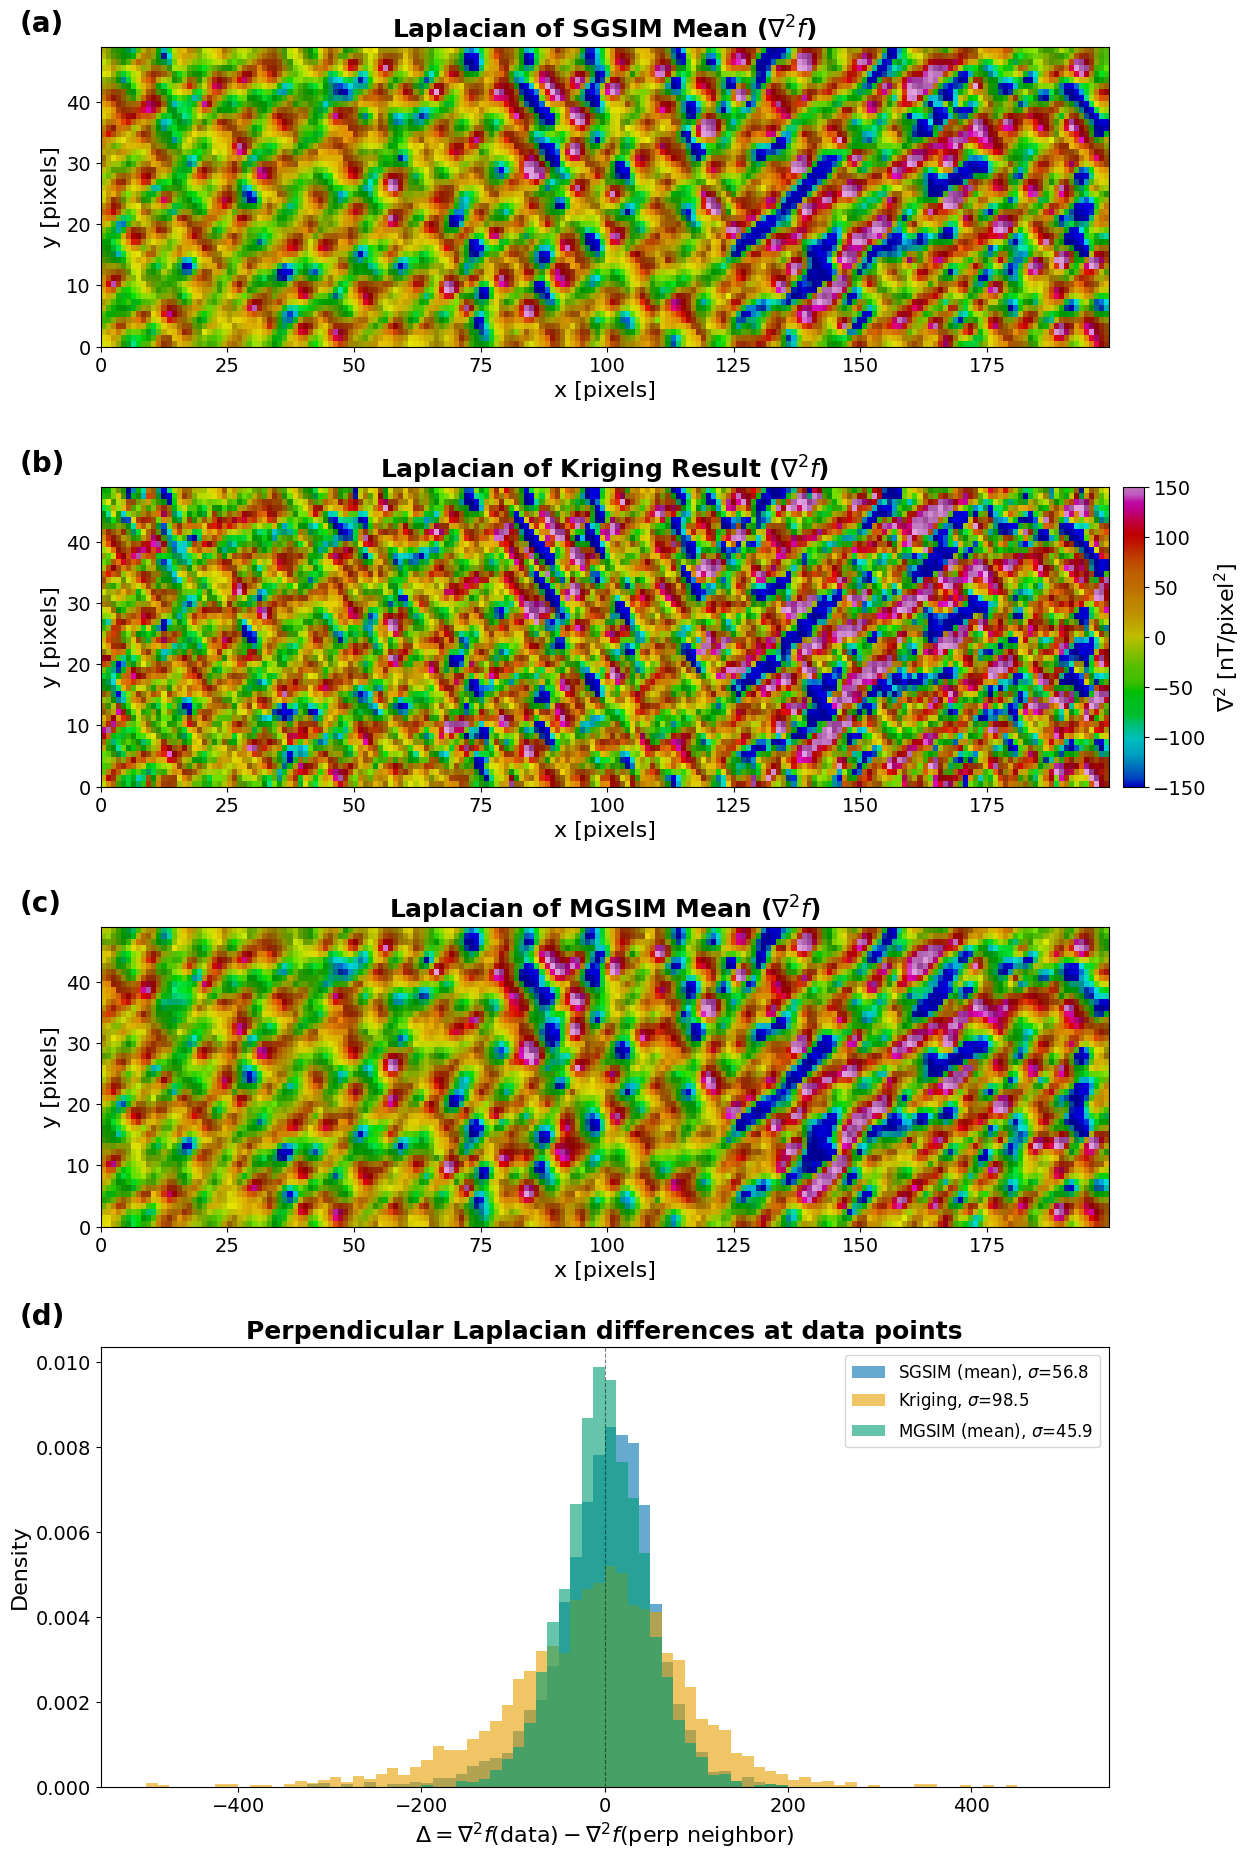

In [299]:
## FIGURE: Laplacian comparison — SGSIM vs Kriging vs MGSIM ##
## ========================================================= ##

import xarray as xr
from matplotlib.colors import Normalize, LightSource
from matplotlib.cm import ScalarMappable

# Uses variogram_type and linespacing from the data loading cell above
# (Reloads locally to keep this cell self-contained)
vgram_dir_loc = {'spherical': 'sph_vgram', 'gaussian': 'gauss_vgram'}[variogram_type]
base_loc = Path('/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/sherlock') / vgram_dir_loc

print(f"Laplacian figure: variogram={variogram_type}, linespacing={linespacing}")

sgsim_files = sorted((base_loc / 'standard_geostats' / linespacing).glob('sgsim_realizations_*.nc'))
ds_sgsim_loc = xr.open_mfdataset(sgsim_files, combine='nested', concat_dim='realization')
sgsim_mean = ds_sgsim_loc['simulated'].mean(dim='realization').values

mgsim_files = sorted((base_loc / f'iso_subregions_{linespacing}').glob('realizations_*.nc'))
ds_mgsim_loc = xr.open_mfdataset(mgsim_files, combine='nested', concat_dim='realization')
mgsim_mean = ds_mgsim_loc['simulated'].mean(dim='realization').values

ds_krig_loc = xr.open_dataset(base_loc / 'standard_geostats' / linespacing / 'kriging_result.nc')
krig_pred = ds_krig_loc['kriging_pred'].values

rows, cols = mgsim_mean.shape

extent = [float(ds_mgsim_loc.x.min()), float(ds_mgsim_loc.x.max()),
          float(ds_mgsim_loc.y.min()), float(ds_mgsim_loc.y.max())]

ls = LightSource(azdeg=315, altdeg=45)

# --- Compute Laplacians via np.gradient ---
dx = (extent[1] - extent[0]) / (cols - 1)
dy = (extent[3] - extent[2]) / (rows - 1)

def compute_laplacian(mat):
    df_dy, df_dx = np.gradient(mat, dy, dx)
    d2f_dyy, _ = np.gradient(df_dy, dy, dx)
    _, d2f_dxx = np.gradient(df_dx, dy, dx)
    return d2f_dxx + d2f_dyy

lap_sgsim = compute_laplacian(sgsim_mean)
lap_krig  = compute_laplacian(krig_pred)
lap_mgsim = compute_laplacian(mgsim_mean)

# --- Observation point locations ---
cfg_data = pd.read_csv('/Users/jrines/stanford_gp/research/mx/computers_geosciences/'
                       f'multigrid-sgsim/configs/config_iso_subregions_{linespacing}_data.csv')
obs = cfg_data[cfg_data['set'] == 1]
obs_rows = obs['y'].astype(int).values
obs_cols = obs['x'].astype(int).values

# --- Perpendicular Laplacian differences ---
def perp_lap_diffs(lap, obs_rows, obs_cols, offset=1):
    diffs = []
    nrows, ncols = lap.shape
    for r, c in zip(obs_rows, obs_cols):
        val = lap[r, c]
        if r + offset < nrows and c + offset < ncols:
            diffs.append(val - lap[r + offset, c + offset])
        if r - offset >= 0 and c - offset >= 0:
            diffs.append(val - lap[r - offset, c - offset])
    return np.array(diffs)

diffs_sgsim = perp_lap_diffs(lap_sgsim, obs_rows, obs_cols, offset=1)
diffs_krig  = perp_lap_diffs(lap_krig, obs_rows, obs_cols, offset=1)
diffs_mgsim = perp_lap_diffs(lap_mgsim, obs_rows, obs_cols, offset=1)

# --- Figure ---
fig = plt.figure(figsize=(14, 20))

lap_vmin, lap_vmax = -150, 150
lap_cmap = geosoft_cmap

lx = 0.10
pw = 0.72
map_ph = 0.15
row_ys = [0.82, 0.60, 0.38]
hist_y, hist_h = 0.10, 0.22

# (a) SGSIM Laplacian
ax_a = fig.add_axes([lx, row_ys[0], pw, map_ph])
rgb_a = ls.shade(lap_sgsim, cmap=lap_cmap, blend_mode='soft', vmin=lap_vmin, vmax=lap_vmax)
ax_a.imshow(rgb_a, origin='lower', extent=extent, aspect='auto')
ax_a.set_title(r'Laplacian of SGSIM Mean ($\nabla^2 f$)', fontsize=18, fontweight='bold')
ax_a.set_xlabel('x [pixels]', fontsize=16); ax_a.set_ylabel('y [pixels]', fontsize=16)
ax_a.tick_params(labelsize=14)
ax_a.text(-0.08, 1.05, '(a)', transform=ax_a.transAxes, fontsize=20, fontweight='bold')

# (b) Kriging Laplacian
ax_b = fig.add_axes([lx, row_ys[1], pw, map_ph])
rgb_b = ls.shade(lap_krig, cmap=lap_cmap, blend_mode='soft', vmin=lap_vmin, vmax=lap_vmax)
ax_b.imshow(rgb_b, origin='lower', extent=extent, aspect='auto')
ax_b.set_title(r'Laplacian of Kriging Result ($\nabla^2 f$)', fontsize=18, fontweight='bold')
ax_b.set_xlabel('x [pixels]', fontsize=16); ax_b.set_ylabel('y [pixels]', fontsize=16)
ax_b.tick_params(labelsize=14)
ax_b.text(-0.08, 1.05, '(b)', transform=ax_b.transAxes, fontsize=20, fontweight='bold')

val_mappable = ScalarMappable(norm=Normalize(vmin=lap_vmin, vmax=lap_vmax), cmap=lap_cmap)
val_mappable.set_array([])
cbar_ax = fig.add_axes([lx + pw + 0.01, row_ys[1], 0.015, map_ph])
cb = fig.colorbar(val_mappable, cax=cbar_ax)
cb.set_label(r'$\nabla^2$ [nT/pixel$^2$]', fontsize=16)
cb.ax.tick_params(labelsize=14)

# (c) MGSIM Laplacian
ax_c = fig.add_axes([lx, row_ys[2], pw, map_ph])
rgb_c = ls.shade(lap_mgsim, cmap=lap_cmap, blend_mode='soft', vmin=lap_vmin, vmax=lap_vmax)
ax_c.imshow(rgb_c, origin='lower', extent=extent, aspect='auto')
ax_c.set_title(r'Laplacian of MGSIM Mean ($\nabla^2 f$)', fontsize=18, fontweight='bold')
ax_c.set_xlabel('x [pixels]', fontsize=16); ax_c.set_ylabel('y [pixels]', fontsize=16)
ax_c.tick_params(labelsize=14)
ax_c.text(-0.08, 1.05, '(c)', transform=ax_c.transAxes, fontsize=20, fontweight='bold')

# (d) Perpendicular Laplacian differences
ax_d = fig.add_axes([lx, hist_y, pw, hist_h])
bins = np.linspace(-500, 500, 81)

ax_d.hist(diffs_sgsim, bins=bins, density=True, alpha=0.6,
          color='#0072B2', edgecolor='none',
          label=f'SGSIM (mean), $\\sigma$={diffs_sgsim.std():.1f}')
ax_d.hist(diffs_krig, bins=bins, density=True, alpha=0.6,
          color='#E69F00', edgecolor='none',
          label=f'Kriging, $\\sigma$={diffs_krig.std():.1f}')
ax_d.hist(diffs_mgsim, bins=bins, density=True, alpha=0.6,
          color='#009E73', edgecolor='none',
          label=f'MGSIM (mean), $\\sigma$={diffs_mgsim.std():.1f}')

ax_d.axvline(0, color='k', ls='--', lw=0.8, alpha=0.5)
ax_d.set_xlabel(r'$\Delta = \nabla^2 f(\mathrm{data}) - \nabla^2 f(\mathrm{perp\ neighbor})$', fontsize=16)
ax_d.set_ylabel('Density', fontsize=16)
ax_d.set_title('Perpendicular Laplacian differences at data points',
               fontsize=18, fontweight='bold')
ax_d.legend(fontsize=12)
ax_d.tick_params(labelsize=14)
ax_d.text(-0.08, 1.05, '(d)', transform=ax_d.transAxes, fontsize=20, fontweight='bold')

# save fig
fig.savefig("/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/figures/fig06_laplacians.png",
            bbox_inches='tight', dpi=300)

plt.show()

## Figure 7: error maps

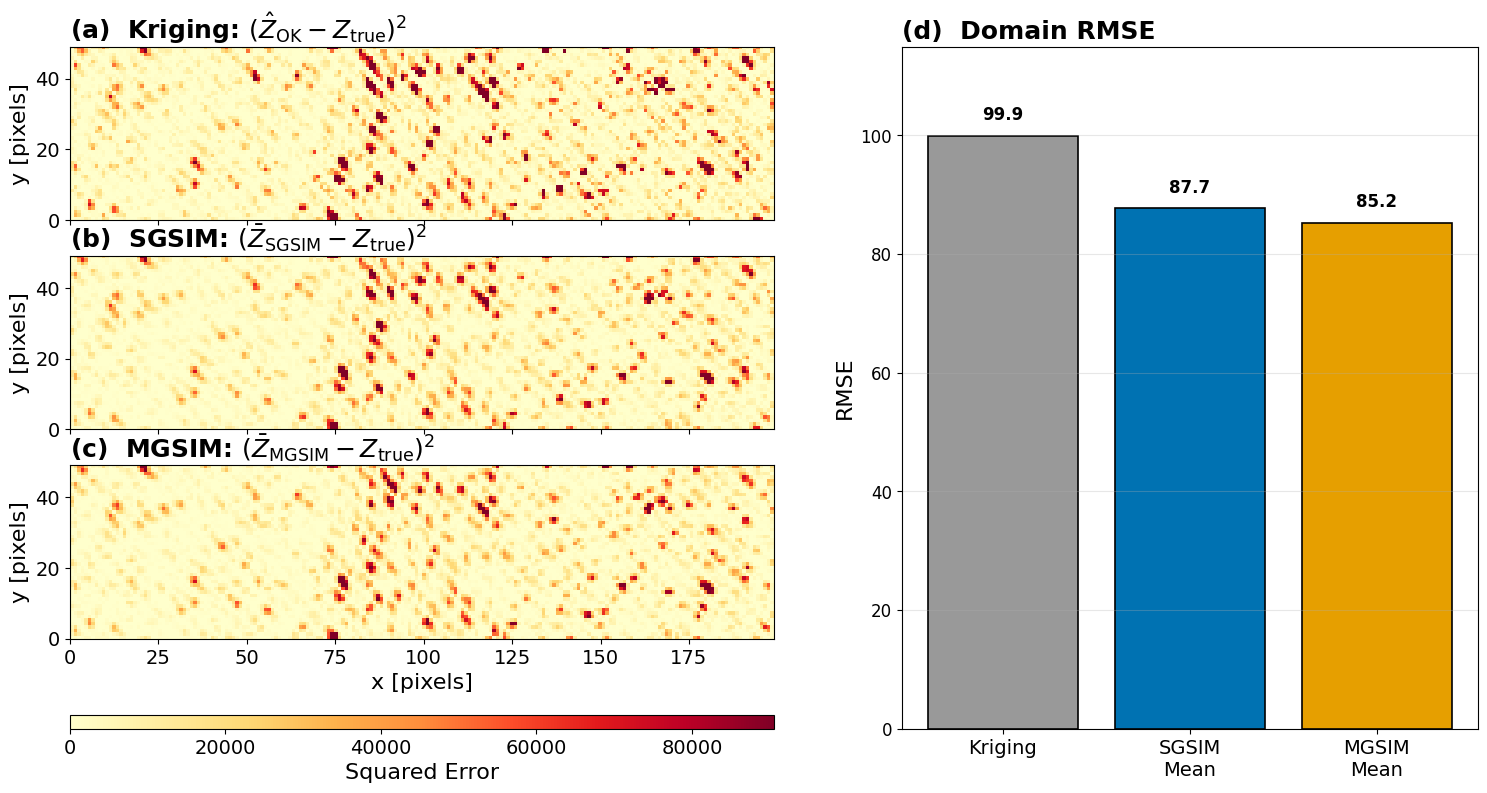


RMSE summary:
  Kriging              99.9
  SGSIM Mean           87.7
  MGSIM Mean           85.2


In [300]:
## FIGURE: Pixel-wise Squared Error — 3×1 + bar chart ##
## ==================================================== ##

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# --- Load ground truth ---
gt_path = '/Users/jrines/stanford_gp/research/mx/computers_geosciences/data/synthetic_magnetic_groundtruth.csv'
df_gt = pd.read_csv(gt_path)
ground_truth = df_gt['val'].values.reshape(
    df_gt['y'].nunique(), df_gt['x'].nunique()
)

extent = [float(ds_mgsim.x.min()), float(ds_mgsim.x.max()),
          float(ds_mgsim.y.min()), float(ds_mgsim.y.max())]

# --- Compute squared errors ---
se_krig       = (krig_pred - ground_truth) ** 2
se_sgsim_mean = (sgsim_mean - ground_truth) ** 2
se_mgsim_mean = (mgsim_mean - ground_truth) ** 2

all_se = np.concatenate([se_krig.ravel(), se_sgsim_mean.ravel(),
                         se_mgsim_mean.ravel()])
se_vmax = np.nanpercentile(all_se, 99)

# --- RMSE ---
rmse_vals = [
    np.sqrt(np.nanmean(se_krig)),
    np.sqrt(np.nanmean(se_sgsim_mean)),
    np.sqrt(np.nanmean(se_mgsim_mean)),
]
bar_labels = ['Kriging', 'SGSIM\nMean', 'MGSIM\nMean']
bar_colors = ['#999999', '#0072B2', '#E69F00']

# --- Layout ---
fig_w, fig_h = 16, 9
fig = plt.figure(figsize=(fig_w, fig_h))

lx = 0.06
pw = 0.44

data_aspect = (extent[3] - extent[2]) / (extent[1] - extent[0])
ph = pw * data_aspect * (fig_w / fig_h)

gap = 0.04
row_y = [0.72, 0.72 - ph - gap, 0.72 - 2*(ph + gap)]
cbar_y = row_y[2] - 0.10
cmap_se = 'YlOrRd'

panels = [
    (0, se_krig,       r'(a)  Kriging: $(\hat{Z}_{\mathrm{OK}} - Z_{\mathrm{true}})^2$'),
    (1, se_sgsim_mean, r'(b)  SGSIM: $(\bar{Z}_{\mathrm{SGSIM}} - Z_{\mathrm{true}})^2$'),
    (2, se_mgsim_mean, r'(c)  MGSIM: $(\bar{Z}_{\mathrm{MGSIM}} - Z_{\mathrm{true}})^2$'),
]

im = None
for row, se, title in panels:
    ax = fig.add_axes([lx, row_y[row], pw, ph])
    im = ax.imshow(se, origin='lower', extent=extent, aspect='auto',
                   cmap=cmap_se, vmin=0, vmax=se_vmax)
    ax.set_title(title, fontsize=18, fontweight='bold', loc='left')
    ax.set_ylabel('y [pixels]', fontsize=16)
    ax.tick_params(labelsize=14)
    if row == 2:
        ax.set_xlabel('x [pixels]', fontsize=16)
    else:
        ax.set_xticklabels([])

# Colorbar — horizontal, below bottom panel
cbar_ax = fig.add_axes([lx, cbar_y, pw, 0.015])
cb = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cb.set_label('Squared Error', fontsize=16)
cb.ax.tick_params(labelsize=14)

# (d) RMSE bar chart — right column, spans full height of the 3 panels
rx = 0.58
rw = 0.36
bar_bottom = cbar_y
bar_top = row_y[0] + ph
ax_bar = fig.add_axes([rx, bar_bottom, rw, bar_top - bar_bottom])
bars = ax_bar.bar(range(len(rmse_vals)), rmse_vals, color=bar_colors,
                  edgecolor='black', linewidth=1.2)

ax_bar.set_xticks(range(len(rmse_vals)))
ax_bar.set_xticklabels(bar_labels, fontsize=14)
ax_bar.set_ylabel('RMSE', fontsize=16)
ax_bar.set_title('(d)  Domain RMSE', fontsize=18, fontweight='bold', loc='left')
ax_bar.tick_params(axis='y', labelsize=12)
ax_bar.grid(axis='y', alpha=0.3)

for j, v in enumerate(rmse_vals):
    ax_bar.text(j, v + max(rmse_vals) * 0.02, f'{v:.1f}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')
ax_bar.set_ylim(0, max(rmse_vals) * 1.15)

# save fig
fig.savefig("/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/figures/fig07_errmaps.png",
            bbox_inches='tight', dpi=300)

plt.show()

# --- Print summary ---
print("\nRMSE summary:")
for label, rmse in zip(bar_labels, rmse_vals):
    print(f"  {label.replace(chr(10), ' '):<16} {rmse:>8.1f}")


## Figure 9: CSB results

In [264]:
# ## FIGURE: CSB MGSIM Results — Realizations, Mean, Variance ##
# ## =========================================================== ##

# import xarray as xr
# from matplotlib.colors import Normalize
# from matplotlib.cm import ScalarMappable

# # --- Load CSB MGSIM results ---
# csb_dir = Path('/Users/jrines/stanford_gp/research/mx/computers_geosciences/'
#                'revision01/sherlock/csb/csb_mat_nst')
# csb_files = sorted(csb_dir.glob('realizations_*.nc'))
# print(f"Loading {len(csb_files)} batch files...")
# ds_csb = xr.open_mfdataset(csb_files, combine='nested', concat_dim='realization')
# ds_csb = ds_csb.sortby('realization')
# sim = ds_csb['simulated']  # (1000, 248, 426)
# print(f"Loaded: {sim.shape[0]} realizations, grid {sim.shape[1]}x{sim.shape[2]}")

# # --- Compute summary maps ---
# csb_mean = sim.mean(dim='realization').values
# csb_var  = sim.var(dim='realization').values
# rows_csb, cols_csb = csb_mean.shape

# # --- Coordinates in km ---
# x_km = ds_csb.x.values / 1000.0
# y_km = ds_csb.y.values / 1000.0
# extent_csb = [x_km.min(), x_km.max(), y_km.min(), y_km.max()]

# # --- Color limits ---
# vmin_val, vmax_val = -1200, 3600
# vmin_var, vmax_var = 0, np.nanpercentile(csb_var, 99)

# # --- Padded extent for contour (so outline closes at array edges) ---
# px = (extent_csb[1] - extent_csb[0]) / (cols_csb - 1)
# py = (extent_csb[3] - extent_csb[2]) / (rows_csb - 1)
# padded_extent = [extent_csb[0] - px, extent_csb[1] + px,
#                  extent_csb[2] - py, extent_csb[3] + py]

# # --- Figure ---
# fig = plt.figure(figsize=(14, 20))

# lx = 0.08
# pw = 0.74
# ph = 0.20
# cb_x = lx + pw + 0.035
# cb_w = 0.02

# # ===== (a) Fanned-out realizations =====
# real_indices = [0, 42, 200]
# n_stack = len(real_indices)
# dx_off, dy_off = 0.01, 0.01
# stack_y0 = 0.70

# for i, ridx in enumerate(real_indices):
#     mat = sim.sel(realization=ridx).values

#     ax = fig.add_axes([lx + i * dx_off,
#                        stack_y0 + (n_stack - 1 - i) * dy_off,
#                        pw, ph])
#     ax.set_facecolor('none')
#     ax.imshow(mat, origin='lower', extent=extent_csb, aspect='auto',
#               cmap=geosoft_cmap, vmin=vmin_val, vmax=vmax_val)
#     ax.set_xticks([])
#     ax.set_yticks([])
#     for spine in ax.spines.values():
#         spine.set_visible(False)

#     # Pad valid mask so contour closes at array edges
#     valid_mask = (~np.isnan(mat)).astype(float)
#     padded = np.pad(valid_mask, 1, mode='constant', constant_values=0)
#     ax.contour(padded, levels=[0.5], colors='black', linewidths=4,
#                extent=padded_extent, origin='lower')

# # Title and label
# title_x = lx + pw / 2 + (n_stack - 1) * dx_off / 2
# title_y = stack_y0 + ph + (n_stack - 1) * dy_off + 0.01
# fig.text(title_x, title_y, 'MGSIM Realizations',
#          ha='center', fontsize=20, fontweight='bold')
# fig.text(lx - 0.04, stack_y0 + ph + (n_stack - 1) * dy_off + 0.01,
#          '(a)', fontsize=22, fontweight='bold')

# # ===== (b) Ensemble mean =====
# mean_y0 = 0.42
# ax_b = fig.add_axes([lx, mean_y0, pw, ph])
# ax_b.imshow(csb_mean, origin='lower', extent=extent_csb, aspect='auto',
#             cmap=geosoft_cmap, vmin=vmin_val, vmax=vmax_val)
# ax_b.set_facecolor('white')
# ax_b.set_ylabel('Northing [km]', fontsize=18)
# ax_b.set_title('MGSIM Ensemble Mean', fontsize=20, fontweight='bold')
# ax_b.tick_params(labelsize=16)
# ax_b.set_xticklabels([])
# ax_b.text(-0.08, 1.05, '(b)', transform=ax_b.transAxes,
#           fontsize=22, fontweight='bold')

# # Shared colorbar for (a) and (b)
# sm_val = ScalarMappable(norm=Normalize(vmin=vmin_val, vmax=vmax_val), cmap=geosoft_cmap)
# sm_val.set_array([])
# cbar_val_ax = fig.add_axes([cb_x, mean_y0, cb_w,
#                             stack_y0 + ph - mean_y0])
# cb_val = fig.colorbar(sm_val, cax=cbar_val_ax)
# cb_val.set_label('RMI [nT]', fontsize=18)
# cb_val.ax.tick_params(labelsize=14)

# # ===== (c) Variance =====
# var_y0 = 0.14
# ax_c = fig.add_axes([lx, var_y0, pw, ph])
# ax_c.imshow(csb_var, origin='lower', extent=extent_csb, aspect='auto',
#             cmap=plt.cm.YlGnBu_r, vmin=vmin_var, vmax=vmax_var)
# ax_c.set_facecolor('white')
# ax_c.set_xlabel('Easting [km]', fontsize=18)
# ax_c.set_ylabel('Northing [km]', fontsize=18)
# ax_c.set_title('MGSIM Ensemble Variance', fontsize=20, fontweight='bold')
# ax_c.tick_params(labelsize=16)
# ax_c.text(-0.08, 1.05, '(c)', transform=ax_c.transAxes,
#           fontsize=22, fontweight='bold')

# # Variance colorbar
# sm_var = ScalarMappable(norm=Normalize(vmin=vmin_var, vmax=vmax_var), cmap='YlGnBu_r')
# sm_var.set_array([])
# cbar_var_ax = fig.add_axes([cb_x, var_y0, cb_w, ph])
# cb_var = fig.colorbar(sm_var, cax=cbar_var_ax)
# cb_var.set_label('Variance [nT$^2$]', fontsize=18)
# cb_var.ax.tick_params(labelsize=14)

# # save fig
# fig.savefig("/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/figures/fig08_csb.png",
#             bbox_inches='tight', dpi=300)

# plt.show()


Loading 50 batch files...
Loaded: 1000 realizations, grid 248x426


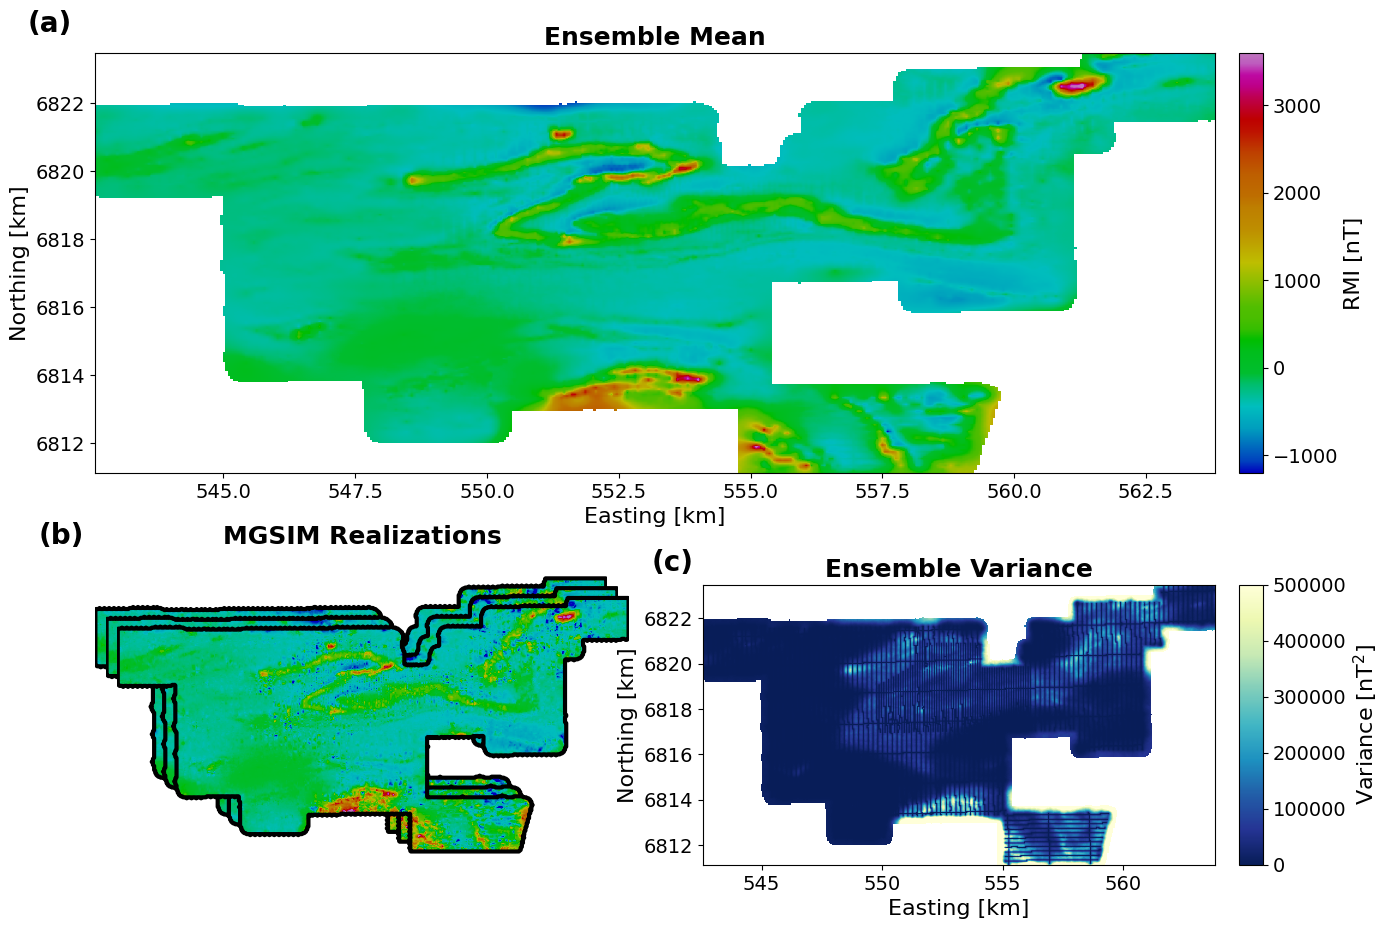

In [301]:
## FIGURE: CSB MGSIM Results — Mean, Realizations, Variance ##
## =========================================================== ##

import xarray as xr
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# --- Load CSB MGSIM results ---
csb_dir = Path('/Users/jrines/stanford_gp/research/mx/computers_geosciences/'
               'revision01/sherlock/csb/csb_mat_nst')
csb_files = sorted(csb_dir.glob('realizations_*.nc'))
print(f"Loading {len(csb_files)} batch files...")
ds_csb = xr.open_mfdataset(csb_files, combine='nested', concat_dim='realization')
ds_csb = ds_csb.sortby('realization')
sim = ds_csb['simulated']
print(f"Loaded: {sim.shape[0]} realizations, grid {sim.shape[1]}x{sim.shape[2]}")

# --- Compute summary maps ---
csb_mean = sim.mean(dim='realization').values
csb_var  = sim.var(dim='realization').values
rows_csb, cols_csb = csb_mean.shape

# --- Coordinates in km ---
x_km = ds_csb.x.values / 1000.0
y_km = ds_csb.y.values / 1000.0
extent_csb = [x_km.min(), x_km.max(), y_km.min(), y_km.max()]

# --- Color limits ---
vmin_val, vmax_val = -1200, 3600
vmin_var, vmax_var = 0, 500000

# --- Padded extent for contour ---
px = (extent_csb[1] - extent_csb[0]) / (cols_csb - 1)
py = (extent_csb[3] - extent_csb[2]) / (rows_csb - 1)
padded_extent = [extent_csb[0] - px, extent_csb[1] + px,
                 extent_csb[2] - py, extent_csb[3] + py]

# --- Figure ---
fig = plt.figure(figsize=(16, 14))

# Shared horizontal reference: all panels aligned to same left/right edges
LEFT   = 0.08           # left edge of all map panels
CB_GAP = 0.015          # gap between map and colorbar
CB_W   = 0.015          # colorbar width

# --- Top row (ensemble mean) ---
top_pw = 0.70
top_ph = 0.30
top_y0 = 0.40

# --- Bottom row (realizations left, variance right) ---
bot_pw = 0.32           # each bottom panel width
bot_ph = 0.20
bot_y0 = 0.12
gap_h  = 0.06           # horizontal gap between bottom panels
bot_rx = LEFT + bot_pw + gap_h  # right panel x

# ===== (a) Ensemble mean — top =====
sm_val = ScalarMappable(norm=Normalize(vmin=vmin_val, vmax=vmax_val), cmap=geosoft_cmap)
sm_val.set_array([])

ax_a = fig.add_axes([LEFT, top_y0, top_pw, top_ph])
ax_a.imshow(csb_mean, origin='lower', extent=extent_csb, aspect='auto',
            cmap=geosoft_cmap, vmin=vmin_val, vmax=vmax_val)
ax_a.set_facecolor('white')
ax_a.set_xlabel('Easting [km]', fontsize=16)
ax_a.set_ylabel('Northing [km]', fontsize=16)
ax_a.set_title('Ensemble Mean', fontsize=18, fontweight='bold')
ax_a.tick_params(labelsize=14)
ax_a.text(-0.06, 1.05, '(a)', transform=ax_a.transAxes,
          fontsize=20, fontweight='bold')

cbar_a_ax = fig.add_axes([LEFT + top_pw + CB_GAP, top_y0, CB_W, top_ph])
cb_a = fig.colorbar(sm_val, cax=cbar_a_ax)
cb_a.set_label('RMI [nT]', fontsize=16)
cb_a.ax.tick_params(labelsize=14)

# ===== (b) Fanned-out realizations — bottom left =====
real_indices = [0, 42, 200]
n_stack = len(real_indices)
dx_off, dy_off = 0.007, 0.007

for i, ridx in enumerate(real_indices):
    mat = sim.sel(realization=ridx).values
    ax = fig.add_axes([LEFT + i * dx_off,
                       bot_y0 + (n_stack - 1 - i) * dy_off,
                       bot_pw, bot_ph])
    ax.set_facecolor('none')
    ax.imshow(mat, origin='lower', extent=extent_csb, aspect='auto',
              cmap=geosoft_cmap, vmin=vmin_val, vmax=vmax_val)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    valid_mask = (~np.isnan(mat)).astype(float)
    padded = np.pad(valid_mask, 1, mode='constant', constant_values=0)
    ax.contour(padded, levels=[0.5], colors='black', linewidths=3,
               extent=padded_extent, origin='lower')

fan_cx = LEFT + bot_pw / 2 + (n_stack - 1) * dx_off / 2
fan_top = bot_y0 + bot_ph + (n_stack - 1) * dy_off
fig.text(fan_cx, fan_top + 0.015, 'MGSIM Realizations',
         ha='center', fontsize=18, fontweight='bold')
fig.text(LEFT - 0.035, fan_top + 0.015,
         '(b)', fontsize=20, fontweight='bold')

# ===== (c) Variance — bottom right =====
ax_c = fig.add_axes([bot_rx, bot_y0, bot_pw, bot_ph])
ax_c.imshow(csb_var, origin='lower', extent=extent_csb, aspect='auto',
            cmap=plt.cm.YlGnBu_r, vmin=vmin_var, vmax=vmax_var)
ax_c.set_facecolor('white')
ax_c.set_xlabel('Easting [km]', fontsize=16)
ax_c.set_ylabel('Northing [km]', fontsize=16)
ax_c.set_title('Ensemble Variance', fontsize=18, fontweight='bold')
ax_c.tick_params(labelsize=14)
ax_c.text(-0.10, 1.05, '(c)', transform=ax_c.transAxes,
          fontsize=20, fontweight='bold')

sm_var = ScalarMappable(norm=Normalize(vmin=vmin_var, vmax=vmax_var), cmap='YlGnBu_r')
sm_var.set_array([])
cbar_c_ax = fig.add_axes([bot_rx + bot_pw + CB_GAP, bot_y0, CB_W, bot_ph])
cb_c = fig.colorbar(sm_var, cax=cbar_c_ax)
cb_c.set_label('Variance [nT$^2$]', fontsize=16)
cb_c.ax.tick_params(labelsize=14)

fig.savefig("/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/figures/fig09_csb.png",
            bbox_inches='tight', dpi=300)

plt.show()


## Figure A1 (prospectivity)

In [302]:
# =============================================================================
# Bayesian Prospectivity — Cape Smith Belt MGSIM Ensemble
# Part 1: Data loading & posterior computation
# =============================================================================
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import gaussian_kde
from pathlib import Path
from datetime import datetime

RESULTS_DIR = Path('/Users/jrines/stanford_gp/research/mx/computers_geosciences'
                   '/revision01/sherlock/csb/csb_mat_nst')
DATA_DIR = Path('/Users/jrines/stanford_gp/research/mx/computers_geosciences/data')

# --- 1. Load MGSIM ensemble ---
print(f"[{datetime.now():%H:%M:%S}] Loading ensemble...")
nc_files = sorted(RESULTS_DIR.glob('realizations_*.nc'))
ds = xr.open_mfdataset(nc_files, combine='nested', concat_dim='realization')
sim = ds['simulated'].values                       # (1000, 248, 426)
x_coords, y_coords = ds['x'].values, ds['y'].values
n_real, rows, cols = sim.shape
x_km, y_km = x_coords / 1000, y_coords / 1000
extent_km = [x_km[0], x_km[-1], y_km[0], y_km[-1]]
ens_mean = np.nanmean(sim, axis=0)
valid_mask = np.isfinite(sim[0])
print(f"  {n_real} realizations, {rows}x{cols}")

# --- 2. Match lithology drill holes → flight-line RMI values ---
print(f"[{datetime.now():%H:%M:%S}] Matching lithology → RMI...")
df_lith = pd.read_csv(DATA_DIR / 'lithologies_updated.csv')
df_csb  = pd.read_csv(DATA_DIR / 'csb_xyvmmc.csv')
df_fl   = df_csb[df_csb['fl_mask'] == 1]
obs_x, obs_y, obs_rmi = df_fl['x'].values, df_fl['y'].values, df_fl['val'].values

intr  = df_lith[df_lith['intrusive'] == 1]
nintr = df_lith[df_lith['intrusive'] == 0]
half = 25.0  # gridsize/2 = 50/2

int_flag  = np.zeros(len(obs_x), dtype=bool)
nint_flag = np.zeros(len(obs_x), dtype=bool)
# Loop over lithology points (646) rather than obs points (17k)
for lx_arr, ly_arr, flag in [(intr['x'].values, intr['y'].values, int_flag),
                              (nintr['x'].values, nintr['y'].values, nint_flag)]:
    for j in range(len(lx_arr)):
        mask = ((obs_x >= lx_arr[j] - half) & (obs_x <= lx_arr[j] + half) &
                (obs_y >= ly_arr[j] - half) & (obs_y <= ly_arr[j] + half))
        flag |= mask

label_int  = int_flag
label_nint = nint_flag & ~int_flag
rmi_int  = obs_rmi[label_int]
rmi_nint = obs_rmi[label_nint]

n_lab = label_int.sum() + label_nint.sum()
prior_i  = float(label_int.sum())  / n_lab
prior_ni = float(label_nint.sum()) / n_lab
print(f"  Prior(int)={prior_i:.4f}, Prior(nint)={prior_ni:.4f}")
print(f"  N_int={len(rmi_int)}, N_nint={len(rmi_nint)}")

# --- 3. KDE likelihoods ---
kde_i  = gaussian_kde(rmi_int)
kde_ni = gaussian_kde(rmi_nint)

# --- 4. Compute posteriors for all 1000 realizations ---
print(f"[{datetime.now():%H:%M:%S}] Computing posteriors...")
post_all = np.full((n_real, rows, cols), np.nan, dtype=np.float32)
for r in range(n_real):
    v = np.isfinite(sim[r])
    vals = sim[r][v]
    li  = kde_i(vals)  * prior_i
    lni = kde_ni(vals) * prior_ni
    d = li + lni; d[d == 0] = 1e-300
    post_all[r][v] = (li / d).astype(np.float32)
    if r % 200 == 0:
        print(f"  {r}/{n_real}")


# --- 5. Logit-space aggregation → mean & variance ---
eps_c = 1e-6
P = np.clip(post_all, eps_c, 1 - eps_c)
L = np.log(P) - np.log1p(-P)             # logits
mu_L  = np.nanmean(L, axis=0)
var_L = np.nanvar(L, axis=0)
p_sig = 1 / (1 + np.exp(-mu_L))          # sigmoid of mean logit
gp = p_sig * (1 - p_sig)
p_mean = p_sig + 0.5 * gp * (1 - 2*p_sig) * var_L   # delta-method mean
p_var  = gp**2 * var_L                                # delta-method variance

# --- 6. Posterior from ensemble mean RMI ---
post_ens_mean = np.full((rows, cols), np.nan)
v_em_mask = np.isfinite(ens_mean)
v_em = ens_mean[v_em_mask]
li_em  = kde_i(v_em)  * prior_i
lni_em = kde_ni(v_em) * prior_ni
d_em = li_em + lni_em; d_em[d_em == 0] = 1e-300
post_ens_mean[v_em_mask] = li_em / d_em

print(f"[{datetime.now():%H:%M:%S}] Done.")


[14:50:45] Loading ensemble...


/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_4601/832839848.py:25: RuntimeWarning: Mean of empty slice
  ens_mean = np.nanmean(sim, axis=0)


  1000 realizations, 248x426
[14:50:45] Matching lithology → RMI...
  Prior(int)=0.7917, Prior(nint)=0.2083
  N_int=19, N_nint=5
[14:50:46] Computing posteriors...
  0/1000
  200/1000
  400/1000
  600/1000
  800/1000


/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_4601/832839848.py:83: RuntimeWarning: Mean of empty slice
  mu_L  = np.nanmean(L, axis=0)


[14:50:53] Done.


/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_4601/832839848.py:84: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_L = np.nanvar(L, axis=0)


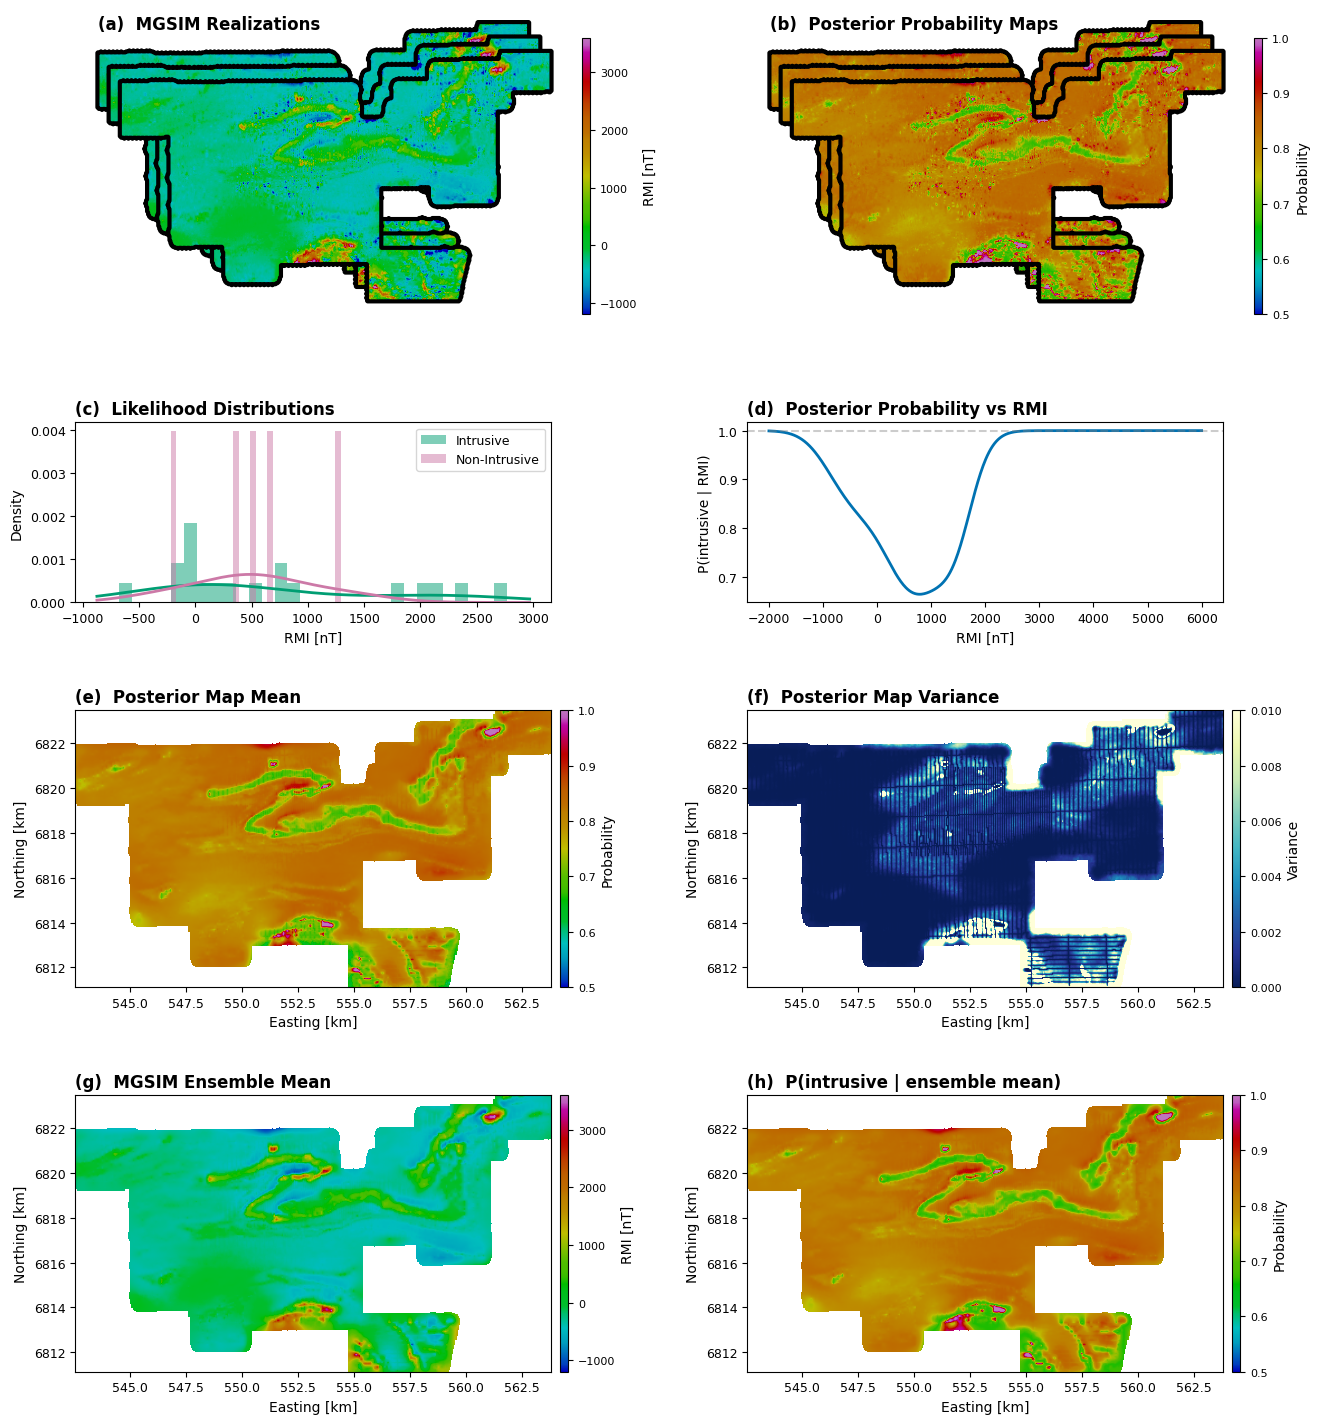

In [303]:
# =============================================================================
# Bayesian Prospectivity Figure — 8 panels (no hillshade)
# =============================================================================
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from utils import geosoft_cmap_k65
geosoft_cmap = geosoft_cmap_k65()

# --- RMI color scaling ---
RMI_VMIN, RMI_VMAX = -1200, 3600

# --- helpers ---
def masked_data(data):
    """Return data with NaN outside valid_mask."""
    out = np.where(valid_mask, data, np.nan)
    return out

def add_outline(ax, lw=2):
    padded = np.pad(valid_mask, 1, constant_values=False)
    dx = (extent_km[1] - extent_km[0]) / (cols - 1)
    dy = (extent_km[3] - extent_km[2]) / (rows - 1)
    pad_ext = [extent_km[0]-dx/2, extent_km[1]+dx/2,
               extent_km[2]-dy/2, extent_km[3]+dy/2]
    ax.contour(padded.astype(float), levels=[0.5], colors='k',
               linewidths=lw, extent=pad_ext, origin='lower')

def strip_ax(ax):
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_facecolor('none'); ax.patch.set_alpha(0)

def add_cb(fig, ax, cmap, vmin, vmax, label):
    pos = ax.get_position()
    cax = fig.add_axes([pos.x1 + 0.006, pos.y0, 0.006, pos.height])
    sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
    sm.set_array([])
    cb = fig.colorbar(sm, cax=cax)
    cb.set_label(label, fontsize=10)
    cb.ax.tick_params(labelsize=8)

def map_axes(fig, ax, data, cmap, vmin, vmax, title, cb_label):
    ax.imshow(masked_data(data), origin='lower', extent=extent_km,
              aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xlabel('Easting [km]', fontsize=10)
    ax.set_ylabel('Northing [km]', fontsize=10)
    ax.tick_params(labelsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold', loc='left')
    add_cb(fig, ax, cmap, vmin, vmax, cb_label)

# --- layout ---
fig = plt.figure(figsize=(14, 18))
pw = 0.34
lx, rx = 0.06, 0.54
asp = (x_km[-1] - x_km[0]) / (y_km[-1] - y_km[0])
ph = pw * 14 / (asp * 18)
hist_h = 0.10
gap = 0.06

r4_y = 0.04
r3_y = r4_y + ph + gap
r2_y = r3_y + ph + gap
r1_y = r2_y + hist_h + gap

n_stack = 3
dx_off, dy_off = 0.008, 0.008
real_indices = [0, 42, 200]

# ---- (a) Fanned MGSIM realizations ----
for i, ri in enumerate(real_indices):
    ax = fig.add_axes([lx + i*dx_off,
                       r1_y + (n_stack-1-i)*dy_off, pw, ph])
    ax.imshow(masked_data(sim[ri]), origin='lower', extent=extent_km,
              aspect='auto', cmap=geosoft_cmap, vmin=RMI_VMIN, vmax=RMI_VMAX)
    add_outline(ax, lw=3); strip_ax(ax)
    if i == n_stack - 1:
        ax.set_title('(a)  MGSIM Realizations',
                     fontsize=12, fontweight='bold', loc='left')
        add_cb(fig, ax, geosoft_cmap, RMI_VMIN, RMI_VMAX, 'RMI [nT]')

# ---- (b) Fanned posterior maps ----
for i, ri in enumerate(real_indices):
    ax = fig.add_axes([rx + i*dx_off,
                       r1_y + (n_stack-1-i)*dy_off, pw, ph])
    ax.imshow(masked_data(post_all[ri]), origin='lower', extent=extent_km,
              aspect='auto', cmap=geosoft_cmap, vmin=0.5, vmax=1.0)
    add_outline(ax, lw=3); strip_ax(ax)
    if i == n_stack - 1:
        ax.set_title('(b)  Posterior Probability Maps',
                     fontsize=12, fontweight='bold', loc='left')
        add_cb(fig, ax, geosoft_cmap, 0.5, 1.0, 'Probability')

# ---- (c) Likelihood distributions ----
ax_c = fig.add_axes([lx, r2_y, pw, hist_h])
ax_c.hist(rmi_int,  bins=30, density=True, alpha=0.5,
          color='#009E73', label='Intrusive')
ax_c.hist(rmi_nint, bins=30, density=True, alpha=0.5,
          color='#CC79A7', label='Non-Intrusive')
xx = np.linspace(min(rmi_int.min(), rmi_nint.min()) - 200,
                 max(rmi_int.max(), rmi_nint.max()) + 200, 300)
ax_c.plot(xx, kde_i(xx),  color='#009E73', lw=2)
ax_c.plot(xx, kde_ni(xx), color='#CC79A7', lw=2)
ax_c.set_xlabel('RMI [nT]', fontsize=10)
ax_c.set_ylabel('Density', fontsize=10)
ax_c.tick_params(labelsize=9)
ax_c.set_title('(c)  Likelihood Distributions',
               fontsize=12, fontweight='bold', loc='left')
ax_c.legend(fontsize=9, loc='upper right', framealpha=0.8)

# ---- (d) Posterior probability vs RMI ----
ax_d = fig.add_axes([rx, r2_y, pw, hist_h])
xx_p = np.linspace(-2000, 6000, 500)
li_c  = kde_i(xx_p)  * prior_i
lni_c = kde_ni(xx_p) * prior_ni
d_c = li_c + lni_c; d_c[d_c == 0] = 1e-300
ax_d.plot(xx_p, li_c / d_c, color='#0072B2', lw=2)
ax_d.axhline(1.0, ls='--', color='gray', alpha=0.4)
ax_d.set_xlabel('RMI [nT]', fontsize=10)
ax_d.set_ylabel('P(intrusive | RMI)', fontsize=10)
ax_d.tick_params(labelsize=9)
ax_d.set_title('(d)  Posterior Probability vs RMI',
               fontsize=12, fontweight='bold', loc='left')

# ---- (e) Posterior map mean ----
ax_e = fig.add_axes([lx, r3_y, pw, ph])
map_axes(fig, ax_e, p_mean, geosoft_cmap, 0.5, 1.0,
         '(e)  Posterior Map Mean', 'Probability')

# ---- (f) Posterior map variance ----
ax_f = fig.add_axes([rx, r3_y, pw, ph])
map_axes(fig, ax_f, p_var, plt.cm.YlGnBu_r, 0, 0.01,
         '(f)  Posterior Map Variance', 'Variance')

# ---- (g) Ensemble mean RMI ----
ax_g = fig.add_axes([lx, r4_y, pw, ph])
map_axes(fig, ax_g, ens_mean, geosoft_cmap, RMI_VMIN, RMI_VMAX,
         '(g)  MGSIM Ensemble Mean', 'RMI [nT]')

# ---- (h) P(intrusive | ensemble mean) ----
ax_h = fig.add_axes([rx, r4_y, pw, ph])
map_axes(fig, ax_h, post_ens_mean, geosoft_cmap, 0.5, 1.0,
         '(h)  P(intrusive | ensemble mean)', 'Probability')

fig.savefig("/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/figures/figA1_prospectivity.png",
            bbox_inches='tight', dpi=300)

plt.show()


## Figure B1: Cross-validation synthetic

Variogram: gaussian
Column 1 (dense):
  dense: 1000 realizations
  iso_global_dense: 1000 realizations
  aniso_subregions_dense: 1000 realizations
Column 2 (sparse):
  sparse: 1000 realizations
  kriging: loaded
  iso_subregions_sparse: 1000 realizations
Flight lines: dense=2500, sparse=1250


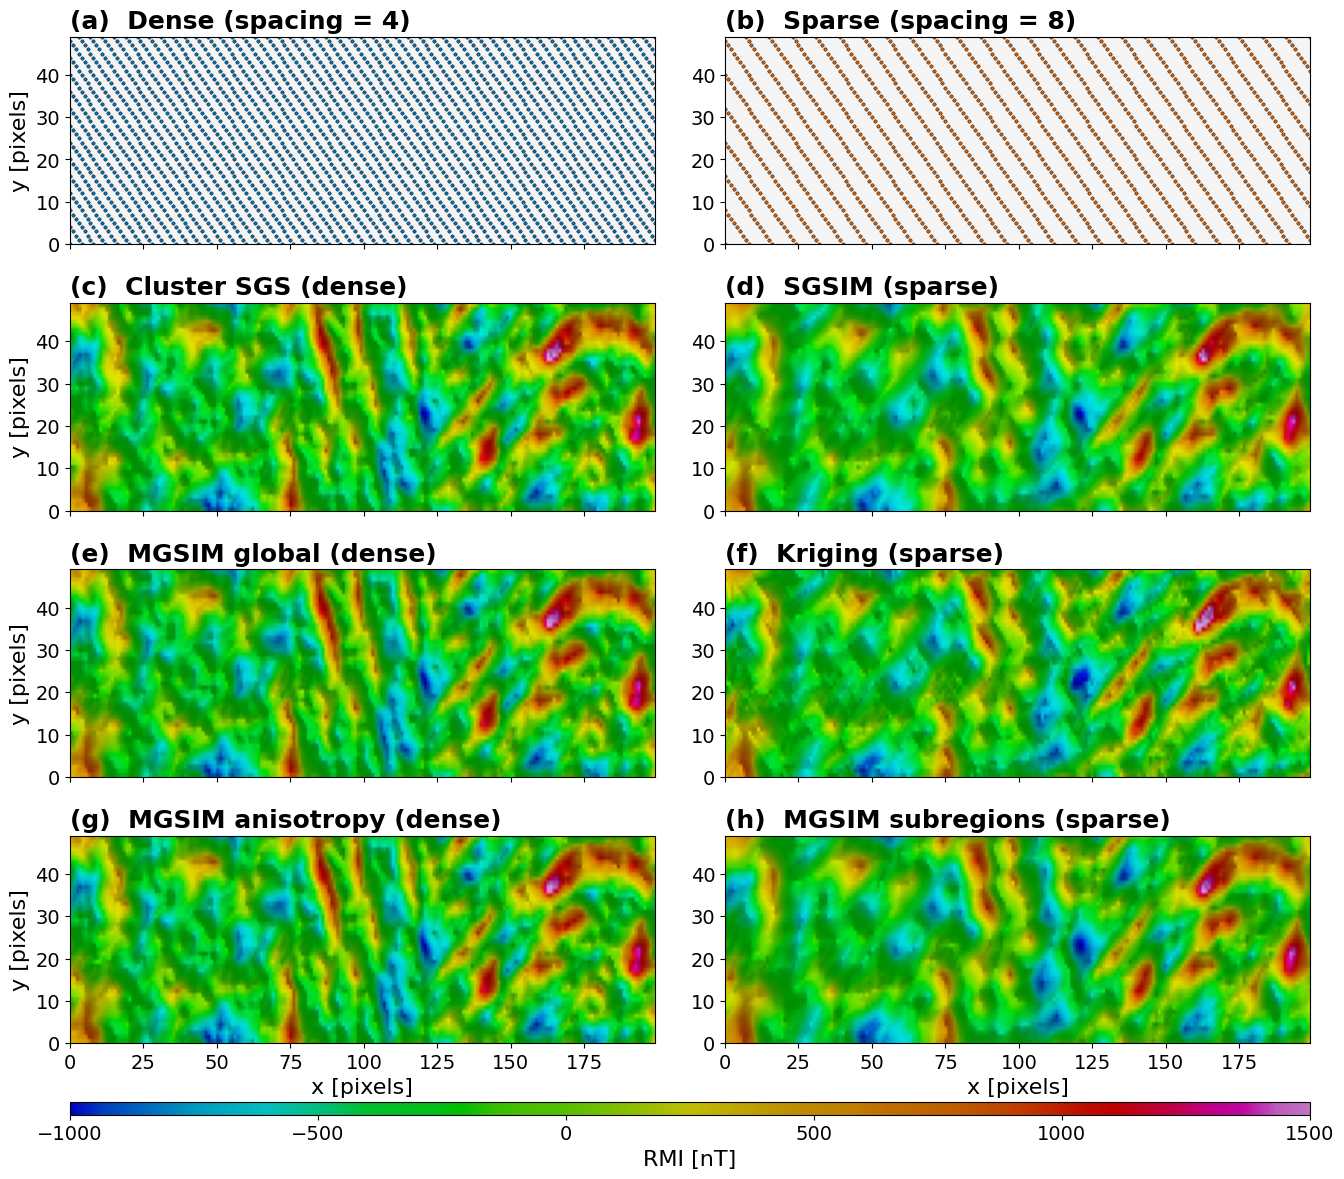

In [312]:
## FIGURE: Method Comparison — 4×2 layout (with flight line maps) ##
## ================================================================ ##

import xarray as xr
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize, LightSource
from matplotlib.cm import ScalarMappable

vgram_dir = {'spherical': 'sph_vgram', 'gaussian': 'gauss_vgram'}[variogram_type]
base = Path('/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/sherlock') / vgram_dir

def load_ensemble_mean(directory, pattern):
    files = sorted(directory.glob(pattern))
    ds = xr.open_mfdataset(files, combine='nested', concat_dim='realization').sortby('realization')
    print(f"  {directory.name}: {ds.sizes['realization']} realizations")
    return ds['simulated'].mean(dim='realization').values, ds

print(f"Variogram: {variogram_type}")

# --- Column 1: dense linespacing ---
print("Column 1 (dense):")
csgs_mean, ds_ref = load_ensemble_mean(base / 'cluster_sgs' / 'dense', 'cluster_sgs_realizations_*.nc')
glob_mean, _      = load_ensemble_mean(base / 'iso_global_dense', 'realizations_*.nc')
aniso_mean, _     = load_ensemble_mean(base / 'aniso_subregions_dense', 'realizations_*.nc')

# --- Column 2: sparse linespacing ---
print("Column 2 (sparse):")
sgsim_sp_mean, _ = load_ensemble_mean(base / 'standard_geostats' / 'sparse', 'sgsim_realizations_*.nc')
ds_krig_sp = xr.open_dataset(base / 'standard_geostats' / 'sparse' / 'kriging_result.nc')
krig_sp = ds_krig_sp['kriging_pred'].values
print(f"  kriging: loaded")
mgsim_sp_mean, _ = load_ensemble_mean(base / 'iso_subregions_sparse', 'realizations_*.nc')

# --- Load flight line positions ---
fl_dir = Path('/Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/demos/data')
fl_dense  = pd.read_csv(fl_dir / 'fl_xyvc_dense.csv')
fl_sparse = pd.read_csv(fl_dir / 'fl_xyvc_sparse.csv')
print(f"Flight lines: dense={len(fl_dense)}, sparse={len(fl_sparse)}")

# --- Plot setup ---
ls = LightSource(azdeg=315, altdeg=45)
vmin, vmax = -1000, 1500
extent = [float(ds_ref.x.min()), float(ds_ref.x.max()),
          float(ds_ref.y.min()), float(ds_ref.y.max())]

def shade(mat):
    return ls.shade(mat, cmap=geosoft_cmap, blend_mode='soft', vmin=vmin, vmax=vmax)

# --- Figure ---
fig = plt.figure(figsize=(16, 11))
gs = gridspec.GridSpec(5, 2, hspace=0.35, wspace=0.12,
                       height_ratios=[1, 1, 1, 1, 0.06],
                       bottom=-0.1)

# ===== Row 0: Flight line locations =====
fl_configs = [
    (0, fl_dense,  '#0072B2', '(a)  Dense (spacing = 4)'),
    (1, fl_sparse, '#D55E00', '(b)  Sparse (spacing = 8)'),
]
for col, fl_data, color, title in fl_configs:
    ax = fig.add_subplot(gs[0, col])
    ax.scatter(fl_data['x'], fl_data['y'], s=6, c=color,
               edgecolors='black', linewidths=0.3, zorder=2)
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_aspect('auto')
    ax.set_title(title, fontsize=18, fontweight='bold', loc='left')
    ax.set_facecolor('#f5f5f5')
    if col == 0:
        ax.set_ylabel('y [pixels]', fontsize=16)
    ax.tick_params(labelsize=14)
    ax.set_xticklabels([])

# ===== Rows 1-3: Method comparison =====
panels = [
    (1, 0, csgs_mean,     '(c)  Cluster SGS (dense)'),
    (1, 1, sgsim_sp_mean, '(d)  SGSIM (sparse)'),
    (2, 0, glob_mean,     '(e)  MGSIM global (dense)'),
    (2, 1, krig_sp,       '(f)  Kriging (sparse)'),
    (3, 0, aniso_mean,    '(g)  MGSIM anisotropy (dense)'),
    (3, 1, mgsim_sp_mean, '(h)  MGSIM subregions (sparse)'),
]

for row, col, data, title in panels:
    ax = fig.add_subplot(gs[row, col])
    ax.imshow(shade(data), origin='lower', extent=extent, aspect='auto')
    ax.set_title(title, fontsize=18, fontweight='bold', loc='left')
    if row == 3:
        ax.set_xlabel('x [pixels]', fontsize=16)
    else:
        ax.set_xticklabels([])
    if col == 0:
        ax.set_ylabel('y [pixels]', fontsize=16)
    ax.tick_params(labelsize=14)

# Colorbar — horizontal, spanning both columns at bottom
cax = fig.add_subplot(gs[4, :])
mappable = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=geosoft_cmap)
mappable.set_array([])
cb = fig.colorbar(mappable, cax=cax, orientation='horizontal')
cb.set_label('RMI [nT]', fontsize=16)
cb.ax.tick_params(labelsize=14)

# save fig
fig.savefig("/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/figures/figB1_crossval.png",
            bbox_inches='tight', dpi=300)

plt.show()


## Figure B2: CSB validation

Loading 50 holdout batch files...
Loaded: (1000, 248, 426)
Holdout observations: 863 points


/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_4601/680302896.py:159: RuntimeWarning: Mean of empty slice
  mean_profile = np.nanmean(profiles_masked, axis=0)
/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_4601/680302896.py:159: RuntimeWarning: Mean of empty slice
  mean_profile = np.nanmean(profiles_masked, axis=0)
/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_4601/680302896.py:159: RuntimeWarning: Mean of empty slice
  mean_profile = np.nanmean(profiles_masked, axis=0)
/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_4601/680302896.py:159: RuntimeWarning: Mean of empty slice
  mean_profile = np.nanmean(profiles_masked, axis=0)


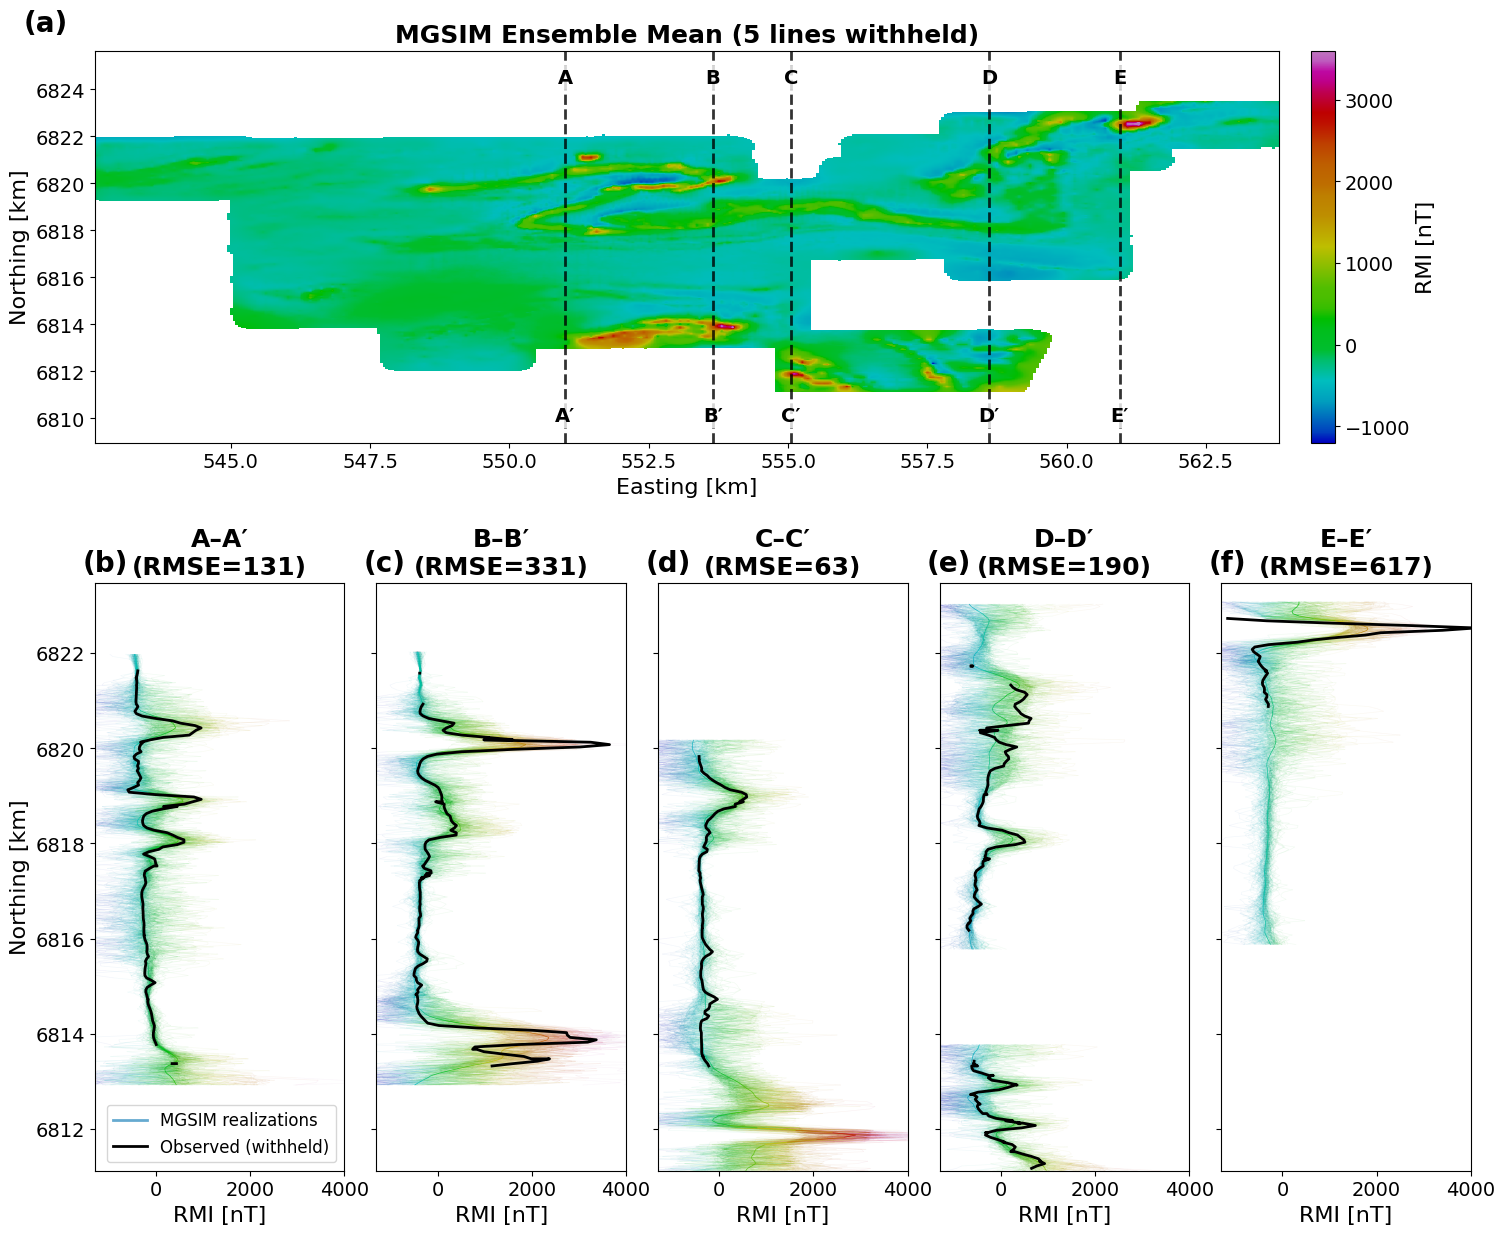

In [305]:
## FIGURE: CSB Holdout Validation — 6 Lines Out (5 profiles) ##
## ============================================================ ##

import xarray as xr
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d

# ---- TOGGLE: color realizations by value or flat blue ----
COLOR_BY_VALUE = True
N_SHOW = 200 if COLOR_BY_VALUE else 1000

# --- Load 6-lines-out MGSIM results ---
ho_dir = Path('/Users/jrines/stanford_gp/research/mx/computers_geosciences/'
              'revision01/sherlock/csb/csb_mat_nst_6linesout')
ho_files = sorted(ho_dir.glob('realizations_*.nc'))
print(f"Loading {len(ho_files)} holdout batch files...")
ds_ho = xr.open_mfdataset(ho_files, combine='nested', concat_dim='realization')
ds_ho = ds_ho.sortby('realization')
sim_ho = ds_ho['simulated']
print(f"Loaded: {sim_ho.shape}")

ho_mean = sim_ho.mean(dim='realization').values
rows_ho, cols_ho = ho_mean.shape

x_m = ds_ho.x.values
y_m = ds_ho.y.values
x_km = x_m / 1000.0
y_km = y_m / 1000.0
extent_ho = [x_km.min(), x_km.max(), y_km.min(), y_km.max()]

df_holdout = pd.read_csv('/Users/jrines/stanford_gp/research/mx/computers_geosciences/'
                         'data/csb_holdout_6lines.csv')
print(f"Holdout observations: {len(df_holdout)} points")

holdout_x_vals = [551000, 553650, 555050, 558610, 560950]
col_indices = [int(np.argmin(np.abs(x_m - xv))) for xv in holdout_x_vals]
section_labels = ['A', 'B', 'C', 'D', 'E']

valid_col_masks = {}
for ci in col_indices:
    valid_col_masks[ci] = np.isfinite(ho_mean[:, ci])

def plot_with_gaps_v(ax, y_vals, z_vals, max_gap_km=0.3, **kwargs):
    """Plot z vs y (vertical profiles: x=RMI, y=Northing) with gap handling."""
    y = np.array(y_vals, dtype=float)
    z = np.array(z_vals, dtype=float)
    if len(y) < 2:
        ax.plot(z, y, **kwargs)
        return
    dy = np.abs(np.diff(y))
    gap_indices = np.where(dy > max_gap_km)[0] + 1
    if len(gap_indices) > 0:
        y = np.insert(y, gap_indices, np.nan)
        z = np.insert(z, gap_indices, np.nan)
    ax.plot(z, y, **kwargs)

def add_colored_profile_v(ax, y_arr, z_arr, cmap, norm, alpha=0.03):
    """Vertical colored profile: x=RMI value, y=Northing."""
    finite = np.isfinite(z_arr)
    if finite.sum() < 2:
        return
    # Points as (z, y) = (RMI, Northing)
    points = np.column_stack([z_arr, y_arr]).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    seg_vals = (z_arr[:-1] + z_arr[1:]) / 2.0
    seg_valid = np.isfinite(seg_vals)
    lc = LineCollection(segments[seg_valid], cmap=cmap, norm=norm,
                        alpha=alpha, linewidths=0.5)
    lc.set_array(seg_vals[seg_valid])
    ax.add_collection(lc)

vmin_val, vmax_val = -1200, 3600
norm_val = Normalize(vmin=vmin_val, vmax=vmax_val)
bbox_props = dict(boxstyle='round,pad=0.15', facecolor='white',
                  edgecolor='none', alpha=0.8)

# --- Figure ---
fig = plt.figure(figsize=(16, 14))

# ===== (a) Map — top =====
map_lx = 0.08
map_pw = 0.74
map_y0 = 0.58
map_ph = 0.28
cb_x = map_lx + map_pw + 0.02
cb_w = 0.015

ax_map = fig.add_axes([map_lx, map_y0, map_pw, map_ph])
ax_map.imshow(ho_mean, origin='lower', extent=extent_ho, aspect='auto',
              cmap=geosoft_cmap, vmin=vmin_val, vmax=vmax_val)
ax_map.set_facecolor('white')

y_top = extent_ho[3]
y_bot = extent_ho[2]
y_pad = (y_top - y_bot) * 0.05

for xv, sl in zip(holdout_x_vals, section_labels):
    xk = xv / 1000.0
    ax_map.axvline(xk, color='black', linewidth=2, linestyle='--', alpha=0.8)
    ax_map.text(xk, y_top + y_pad, sl, ha='center', va='bottom',
                fontsize=14, fontweight='bold', color='black', bbox=bbox_props)
    ax_map.text(xk, y_bot - y_pad, f"{sl}\u2032", ha='center', va='top',
                fontsize=14, fontweight='bold', color='black', bbox=bbox_props)

ax_map.set_ylim(y_bot - 3.5 * y_pad, y_top + 3.5 * y_pad)
ax_map.set_ylabel('Northing [km]', fontsize=16)
ax_map.set_xlabel('Easting [km]', fontsize=16)
ax_map.set_title('MGSIM Ensemble Mean (5 lines withheld)', fontsize=18, fontweight='bold')
ax_map.tick_params(labelsize=14)
ax_map.text(-0.06, 1.05, '(a)', transform=ax_map.transAxes,
            fontsize=20, fontweight='bold')

sm_val = ScalarMappable(norm=norm_val, cmap=geosoft_cmap)
sm_val.set_array([])
cbar_ax = fig.add_axes([cb_x, map_y0, cb_w, map_ph])
cb = fig.colorbar(sm_val, cax=cbar_ax)
cb.set_label('RMI [nT]', fontsize=16)
cb.ax.tick_params(labelsize=14)

# ===== (b)-(f) Vertical profile panels — side by side =====
n_profiles = len(holdout_x_vals)
prof_y0 = 0.06
prof_ph = 0.42
prof_lx = 0.08
prof_total_w = 0.86
prof_gap = 0.02
prof_pw = (prof_total_w - (n_profiles - 1) * prof_gap) / n_profiles

panel_labels = ['(b)', '(c)', '(d)', '(e)', '(f)']
tol = 55
rmi_lo, rmi_hi = -1300, 4000

show_idx = np.linspace(0, sim_ho.shape[0] - 1, N_SHOW, dtype=int)

for j, (xv, ci, plabel, sl) in enumerate(zip(holdout_x_vals,
                                               col_indices,
                                               panel_labels,
                                               section_labels)):
    px0 = prof_lx + j * (prof_pw + prof_gap)
    ax = fig.add_axes([px0, prof_y0, prof_pw, prof_ph])

    valid_mask_col = valid_col_masks[ci]
    profiles = sim_ho[:, :, ci].values
    profiles_masked = profiles.copy()
    profiles_masked[:, ~valid_mask_col] = np.nan

    if COLOR_BY_VALUE:
        for k in show_idx:
            add_colored_profile_v(ax, y_km, profiles_masked[k, :],
                                  geosoft_cmap, norm_val, alpha=0.05)
    else:
        for k in range(profiles_masked.shape[0]):
            ax.plot(profiles_masked[k, :], y_km, color='#0072B2',
                    alpha=0.02, linewidth=0.5)

    mean_profile = np.nanmean(profiles_masked, axis=0)
    mean_profile[~valid_mask_col] = np.nan

    if COLOR_BY_VALUE:
        add_colored_profile_v(ax, y_km, mean_profile, geosoft_cmap, norm_val, alpha=0.9)
    else:
        ax.plot(mean_profile, y_km, color='#0072B2', alpha=0.8, linewidth=2.0)

    # Ground truth
    gt_mask = (df_holdout['x'] - xv).abs() <= tol
    gt = df_holdout[gt_mask].sort_values('y')
    plot_with_gaps_v(ax, gt['y'].values / 1000.0, gt['val'].values,
                     max_gap_km=0.3, color='k', linewidth=2.0, zorder=5)

    # RMSE
    interp_fn = interp1d(y_m, mean_profile, bounds_error=False, fill_value=np.nan)
    pred_at_gt = interp_fn(gt['y'].values)
    valid = np.isfinite(pred_at_gt) & np.isfinite(gt['val'].values)
    rmse = np.sqrt(np.nanmean((pred_at_gt[valid] - gt['val'].values[valid])**2))

    ax.set_xlim(rmi_lo, rmi_hi)
    ax.set_ylim(y_km.min(), y_km.max())
    ax.tick_params(labelsize=14)

    # Title: section label + RMSE
    ax.set_title(f"{sl}\u2013{sl}\u2032\n(RMSE={rmse:.0f})",
                 fontsize=18, fontweight='bold')
    ax.text(-0.05, 1.02, plabel, transform=ax.transAxes,
            fontsize=20, fontweight='bold')

    ax.set_xlabel('RMI [nT]', fontsize=16)

    if j == 0:
        ax.set_ylabel('Northing [km]', fontsize=16)
    else:
        ax.set_yticklabels([])

    # Legend on first panel only
    if j == 0:
        legend_handles = [
            Line2D([0], [0], color='#0072B2', linewidth=2, alpha=0.6,
                   label='MGSIM realizations'),
            Line2D([0], [0], color='k', linewidth=2, label='Observed (withheld)'),
        ]
        ax.legend(handles=legend_handles, fontsize=12, loc='lower right')

fig.savefig("/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/figures/figB2_csbval.png",
            bbox_inches='tight', dpi=300)

plt.show()


## Figure B3: csb variograms

In [140]:
# ## FIGURE: CSB Per-Cluster Variograms ##
# ## =================================== ##

# import json
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from pathlib import Path
# import sys

# sys.path.insert(0, '/Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/src')
# from variograms import cluster_variogram

# # --- Load CSB config + data ---
# cfg_dir = Path('/Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/configs')

# with open(cfg_dir / 'config_csb_sph_iso.json') as f:
#     config = json.load(f)

# df_all = pd.read_csv(cfg_dir / config['data_file'])
# obs = df_all[df_all['set'] == 1].copy()
# obs['cluster'] = obs['cluster'].astype(int)
# obs['residual'] = obs['value'] - obs['trend']

# maxlag = config['metadata']['maxlag']    # 400
# n_lags = config['metadata']['n_lags']    # 30
# model  = config['metadata']['variogram_model']  # 'spherical'
# n_clusters = obs['cluster'].nunique()    # 10

# # Convert coordinates to km for plotting
# obs_x_km = obs['x'].values / 1000.0
# obs_y_km = obs['y'].values / 1000.0

# # --- Fit variograms per cluster ---
# variograms = []
# for i in range(n_clusters):
#     V = cluster_variogram(obs, 'residual', i, maxlag, n_lags, model)
#     r, s, n = V.parameters
#     print(f"  Cluster {i}: range={r:.1f} m, sill={s:.1f}, nugget={n:.4f}, n_obs={len(obs[obs['cluster']==i])}")
#     variograms.append(V)

# # --- Colorblind-safe palette (10 colors) ---
# cluster_colors = plt.cm.tab10(np.arange(n_clusters))

# # --- Build figure ---
# fig = plt.figure(figsize=(20, 20))

# # (a) Data points colored by cluster (top, full width)
# ax_a = fig.add_axes([0.06, 0.78, 0.88, 0.18])
# for ci in range(n_clusters):
#     mask = obs['cluster'] == ci
#     ax_a.scatter(obs_x_km[mask], obs_y_km[mask],
#                  c=[cluster_colors[ci]], s=8, label=f'{ci}', rasterized=True)
# ax_a.set_xlabel('Easting [km]', fontsize=16)
# ax_a.set_ylabel('Northing [km]', fontsize=16)
# ax_a.set_title('CSB data points colored by subregion', fontsize=18, fontweight='bold')
# ax_a.set_aspect('equal')
# ax_a.legend(title='Cluster', markerscale=4, fontsize=12, title_fontsize=13,
#             ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.12))
# ax_a.tick_params(labelsize=14)
# ax_a.text(-0.04, 1.02, '(a)', transform=ax_a.transAxes, fontsize=20, fontweight='bold', va='bottom')

# # (b)-(k) Cluster variograms in 2 rows × 5 columns
# panel_labels = [f'({chr(98+i)})' for i in range(10)]  # (b) through (k)
# ncols_v, nrows_v = 5, 2
# vw, vh = 0.16, 0.14
# x_starts = [0.06 + i * 0.185 for i in range(ncols_v)]
# y_starts = [0.38, 0.16]

# for i, V in enumerate(variograms):
#     row = i // ncols_v
#     col = i % ncols_v
#     ax = fig.add_axes([x_starts[col], y_starts[row], vw, vh])

#     # Empirical variogram
#     ax.scatter(V.bins, V.experimental, c='red', s=40, zorder=3, label='Empirical')

#     # Fitted model curve
#     h = np.linspace(0, V.bins[-1], 200)
#     gamma_model = V.transform(h)
#     ax.plot(h, gamma_model, color='blue', linewidth=2, label='Model')

#     r, s, n = V.parameters
#     ax.set_title(f'Cluster {i}', fontsize=14, fontweight='bold', color=cluster_colors[i])
#     ax.set_xlabel('Lag [m]', fontsize=12)
#     ax.set_ylabel('γ(h)', fontsize=12)
#     ax.set_xlim(0, maxlag)
#     ax.tick_params(labelsize=11)
#     ax.grid(True, alpha=0.3)
#     ax.text(-0.08, 1.02, panel_labels[i], transform=ax.transAxes,
#             fontsize=14, fontweight='bold', va='bottom')

#     if i == 0:
#         ax.legend(fontsize=10)

# # save fig
# fig.savefig("/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/figures/fig??_csbvgrams.png",
#             bbox_inches='tight', dpi=300)

# plt.show()


NST: mean=-0.003, std=1.006
  Cluster 0: range=966 m, sill=0.5147, nugget=0.0000, n=2876
  Cluster 1: range=892 m, sill=0.4129, nugget=0.0000, n=2905
  Cluster 2: range=385 m, sill=2.8105, nugget=0.0000, n=363
  Cluster 3: range=660 m, sill=1.8115, nugget=0.0000, n=1097
  Cluster 4: range=694 m, sill=0.3019, nugget=0.0000, n=2506
  Cluster 5: range=952 m, sill=1.3434, nugget=0.0000, n=434
  Cluster 6: range=402 m, sill=1.6521, nugget=0.0000, n=315
  Cluster 7: range=1546 m, sill=0.3994, nugget=0.0000, n=495
  Cluster 8: range=620 m, sill=1.4974, nugget=0.0000, n=5719
  Cluster 9: range=606 m, sill=1.4995, nugget=0.0000, n=853


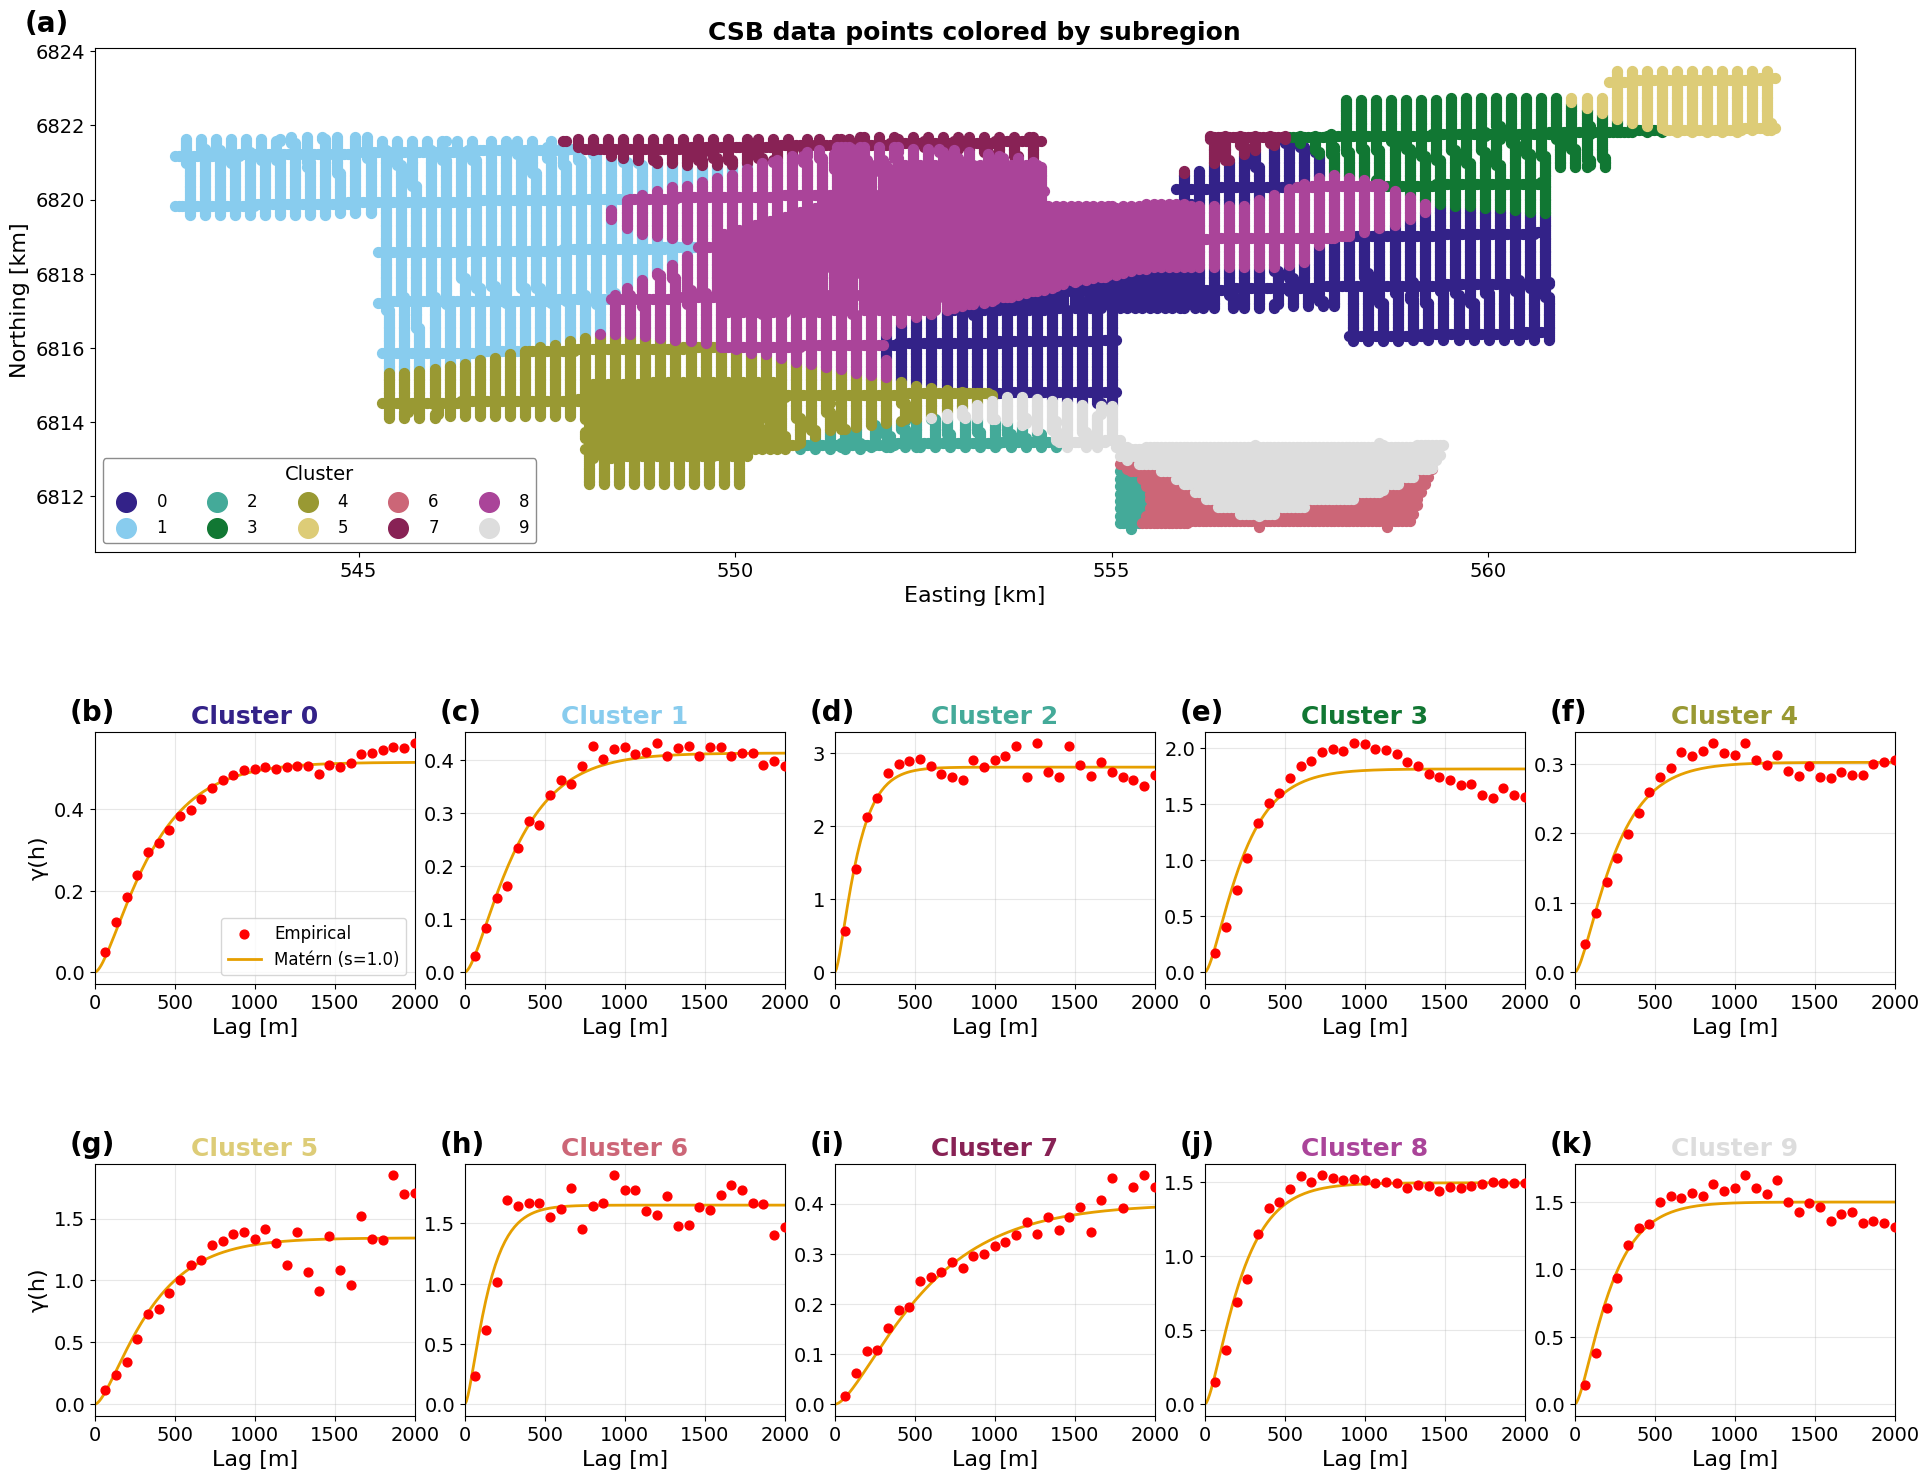

In [307]:
## FIGURE: CSB Per-Cluster Variograms (NST'd residuals, Matérn) ##
## ============================================================= ##

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from sklearn.preprocessing import QuantileTransformer

sys.path.insert(0, '/Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/src')
from variograms import cluster_variogram
import trendmaking
import gstatsim as gs

# --- Settings (match demo_csb_matern_cluster_nst.ipynb) ---
smoothing = 10000.0
spacing_fl = 1000
maxlag = 2000
n_lags = 30
fit_model = 'spherical'
matern_s = 1.0

# --- Load CSB data ---
data_dir = Path('/Users/jrines/stanford_gp/research/mx/computers_geosciences/data')
df_xyvmmc = pd.read_csv(data_dir / 'csb_xyvmmc.csv')

df_fl_only = df_xyvmmc[df_xyvmmc['fl_mask'] == 1].drop(columns=['fl_mask', 'grid_mask'], errors='ignore')
fl_xyvc = df_fl_only.values
grid_xyvc = df_xyvmmc.drop(columns=['fl_mask', 'grid_mask']).values
grid_xyc = np.column_stack([grid_xyvc[:, :2], grid_xyvc[:, 3]])

n_clusters = len(np.unique(fl_xyvc[:, 3]))

# --- Compute trend + residuals ---
fl_xyvct, grid_xyct = trendmaking.make_trend(fl_xyvc, grid_xyc, smoothing, spacing_fl)
residuals = fl_xyvct[:, 2] - fl_xyvct[:, 4]
fl_xyvctr = np.column_stack([fl_xyvct, residuals])

obs = pd.DataFrame(fl_xyvctr, columns=['x', 'y', 'value', 'cluster', 'trend', 'residual'])
obs['cluster'] = obs['cluster'].astype(int)

# --- Fit NST on observation residuals ---
obs_res = obs['residual'].values.reshape(-1, 1)
nst_trans = QuantileTransformer(output_distribution='normal', n_quantiles=min(1000, len(obs_res)))
nst_trans.fit(obs_res)
obs['nst_residual'] = nst_trans.transform(obs_res).ravel()
print(f'NST: mean={obs["nst_residual"].mean():.3f}, std={obs["nst_residual"].std():.3f}')

# --- Fit per-cluster variograms on NST'd residuals ---
variograms = []
for i in range(n_clusters):
    V = cluster_variogram(obs, 'nst_residual', i, maxlag, n_lags, fit_model)
    r, s, n = V.parameters
    n_pts = (obs['cluster'] == i).sum()
    print(f'  Cluster {i}: range={r:.0f} m, sill={s:.4f}, nugget={n:.4f}, n={n_pts}')
    variograms.append(V)

# --- Coordinates in km for map ---
obs_x_km = obs['x'].values / 1000.0
obs_y_km = obs['y'].values / 1000.0

# --- Paul Tol muted palette (10 colorblind-friendly colors) ---
cluster_colors = [
    '#332288',  # indigo
    '#88CCEE',  # cyan
    '#44AA99',  # teal
    '#117733',  # green
    '#999933',  # olive
    '#DDCC77',  # sand
    '#CC6677',  # rose
    '#882255',  # wine
    '#AA4499',  # purple
    '#DDDDDD',  # grey
]

# --- Build figure ---
fig = plt.figure(figsize=(20, 18))

# (a) Data points colored by cluster (top, full width)
ax_a = fig.add_axes([0.06, 0.68, 0.88, 0.28])
for ci in range(n_clusters):
    mask = obs['cluster'] == ci
    ax_a.scatter(obs_x_km[mask], obs_y_km[mask],
                 c=cluster_colors[ci], s=50, label=f'{ci}', rasterized=True)
ax_a.set_xlabel('Easting [km]', fontsize=16)
ax_a.set_ylabel('Northing [km]', fontsize=16)
ax_a.set_title('CSB data points colored by subregion', fontsize=18, fontweight='bold')
ax_a.set_aspect('auto')
ax_a.legend(title='Cluster', markerscale=2, fontsize=12, title_fontsize=14,
            ncol=5, loc='lower left', framealpha=0.9, edgecolor='gray')
ax_a.tick_params(labelsize=14)
ax_a.text(-0.04, 1.02, '(a)', transform=ax_a.transAxes, fontsize=20, fontweight='bold', va='bottom')

# (b)-(k) Cluster variograms in 2 rows × 5 columns
panel_labels = [f'({chr(98+i)})' for i in range(10)]  # (b) through (k)
ncols_v, nrows_v = 5, 2
vw, vh = 0.16, 0.14
x_starts = [0.06 + i * 0.185 for i in range(ncols_v)]
y_starts = [0.44, 0.20]

for i, V in enumerate(variograms):
    row = i // ncols_v
    col = i % ncols_v
    ax = fig.add_axes([x_starts[col], y_starts[row], vw, vh])

    r_cl, s_cl, n_cl = V.parameters

    # Empirical variogram
    ax.scatter(V.bins, V.experimental, c='red', s=40, zorder=3, label='Empirical')

    # Matern model
    h = np.linspace(0, V.bins[-1], 200)
    h_mat = h.copy()
    h_mat[h_mat == 0] = 1e-10
    eff_lag = h_mat / r_cl
    C_mat = gs.Covariance.covar(eff_lag, s_cl, n_cl, 'Matern', s=matern_s)
    gamma_mat = s_cl - C_mat
    ax.plot(h, gamma_mat, '-', color='#E69F00', linewidth=2, label=f'Matérn (s={matern_s})')

    ax.set_title(f'Cluster {i}', fontsize=18, fontweight='bold', color=cluster_colors[i])
    ax.set_xlabel('Lag [m]', fontsize=16)
    if col == 0:
        ax.set_ylabel('γ(h)', fontsize=16)
    else:
        ax.set_ylabel('')

    ax.set_xlim(0, maxlag)
    ax.tick_params(labelsize=14)
    ax.grid(True, alpha=0.3)
    ax.text(-0.08, 1.02, panel_labels[i], transform=ax.transAxes,
            fontsize=20, fontweight='bold', va='bottom')

    if i == 0:
        ax.legend(fontsize=12)

fig.savefig("/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/figures/figB3_csbvgrams_nst.png",
            bbox_inches='tight', dpi=300)

plt.show()
